In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ── THEME ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'        : 120,
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 10,
    'axes.titlesize'    : 12,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 10,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'figure.facecolor'  : '#0F1117',
    'axes.facecolor'    : '#1A1D27',
    'axes.labelcolor'   : 'white',
    'axes.titlecolor'   : 'white',
    'xtick.color'       : 'white',
    'ytick.color'       : 'white',
    'text.color'        : 'white',
    'grid.color'        : '#2A2D3A',
    'grid.linewidth'    : 0.8,
    'grid.alpha'        : 0.5
})

# ── COLOR PALETTES ──────────────────────────────────────
SENSOR_COLORS = {
    '0001' : '#00B4D8',
    '0002' : '#7B2FBE',
    '0003' : '#06D6A0',
    '0004' : '#FF6B35',
    '0005' : '#FFD166',
    '0006' : '#EF476F'
}

POSTURE_COLORS = {
    'Lying Down' : '#EF476F',
    'Sitting'    : '#FFD166',
    'Standing'   : '#06D6A0',
    'Unknown'    : '#6B7280'
}

print('✓ Setup complete')

✓ Setup complete


In [2]:
FILE = r'C:\Users\selas\OneDrive\Documents\Presence Monitoring\Data\presence_data_4.json'

with open(FILE) as f:
    raw = json.load(f)

results = raw['data']['result']

COLS = ['x_pos', 'y_pos', 'z_height',
        'x_motion', 'y_motion', 'z_motion',
        'signal_strength', 'target_count']

records = []
for r in results:
    row = {
        'sensor_id' : r['radarUuid'][-4:],
        'timestamp' : datetime.strptime(
                      r['createTime'], '%Y%m%d%H%M%S'),
        'data_type' : r['dataType']
    }
    for col, val in zip(COLS, r['parsedData']):
        row[col] = val
    records.append(row)

df = pd.DataFrame(records).reset_index(drop=True)
df['hour']    = df['timestamp'].dt.hour
df['date']    = df['timestamp'].dt.date
df['day']     = df['timestamp'].dt.day_name()
df['posture'] = df['z_height'].apply(
    lambda z:
    'Lying Down' if 0.05 <= z <= 0.40 else
    'Sitting'    if 0.41 <= z <= 0.80 else
    'Standing'   if 0.81 <= z <= 1.75 else
    'Unknown'
)

print(f'✓ Loaded {len(df):,} records')

✓ Loaded 160,297 records


In [3]:
# ═══════════════════════════════════════════════
# SECTION 1 — DATASET BASICS
# ═══════════════════════════════════════════════

duration     = (df['timestamp'].max() -
                df['timestamp'].min()).days
n_sensors    = df['sensor_id'].nunique()
n_records    = len(df)
n_variables  = len(COLS)
n_postures   = df['posture'].nunique()
missing      = df.isnull().sum().sum()
date_start   = df['date'].min()
date_end     = df['date'].max()
median_gap   = df.sort_values(
    ['sensor_id','timestamp']).groupby(
    'sensor_id')['timestamp'].diff(
    ).dt.total_seconds().median()

print(f"""
{'='*60}
  VIRTUAL VILLAGE — PRESENCE MONITORING SYSTEM
  DATASET BASIC STATISTICS
{'='*60}

  OVERVIEW
  {'─'*40}
  Total Records      : {n_records:>10,}
  Date Range         : {date_start} → {date_end}
  Duration           : {duration:>10} days
  Sampling Rate      : {median_gap:>10.0f} seconds
  Missing Values     : {missing:>10}

  STRUCTURE
  {'─'*40}
  Total Variables    : {n_variables:>10}
  Target Variables   : {'z_height (posture)':>10}
  Unique Sensors     : {n_sensors:>10}
  Unique Postures    : {n_postures:>10}
  Unique Dates       : {df['date'].nunique():>10}

  SENSORS
  {'─'*40}""")

sensor_counts = df['sensor_id'].value_counts().sort_index()
for s, c in sensor_counts.items():
    pct = 100 * c / n_records
    bar = '█' * int(pct/3)
    print(f'  Sensor {s}       :'
          f' {c:>7,} records ({pct:5.1f}%) {bar}')

print(f"""
  POSTURE DISTRIBUTION
  {'─'*40}""")

posture_counts = df['posture'].value_counts()
for p, c in posture_counts.items():
    pct = 100 * c / n_records
    bar = '█' * int(pct/3)
    print(f'  {p:12s}   :'
          f' {c:>7,} records ({pct:5.1f}%) {bar}')

print(f"""
  Z HEIGHT STATISTICS
  {'─'*40}
  Min Z Height       : {df['z_height'].min():>10.3f} m
  Max Z Height       : {df['z_height'].max():>10.3f} m
  Mean Z Height      : {df['z_height'].mean():>10.3f} m
  Median Z Height    : {df['z_height'].median():>10.3f} m
  Std Z Height       : {df['z_height'].std():>10.3f} m

  SIGNAL STRENGTH
  {'─'*40}
  Min Signal         : {df['signal_strength'].min():>10.3f}
  Max Signal         : {df['signal_strength'].max():>10.3f}
  Mean Signal        : {df['signal_strength'].mean():>10.3f}
{'='*60}
""")


  VIRTUAL VILLAGE — PRESENCE MONITORING SYSTEM
  DATASET BASIC STATISTICS

  OVERVIEW
  ────────────────────────────────────────
  Total Records      :    160,297
  Date Range         : 2026-03-01 → 2026-03-14
  Duration           :         13 days
  Sampling Rate      :          7 seconds
  Missing Values     :          0

  STRUCTURE
  ────────────────────────────────────────
  Total Variables    :          8
  Target Variables   : z_height (posture)
  Unique Sensors     :          6
  Unique Postures    :          4
  Unique Dates       :         14

  SENSORS
  ────────────────────────────────────────
  Sensor 0001       : 114,472 records ( 71.4%) ███████████████████████
  Sensor 0002       :  14,280 records (  8.9%) ██
  Sensor 0003       :  19,185 records ( 12.0%) ███
  Sensor 0004       :   8,947 records (  5.6%) █
  Sensor 0005       :   3,173 records (  2.0%) 
  Sensor 0006       :     240 records (  0.1%) 

  POSTURE DISTRIBUTION
  ────────────────────────────────────────
  

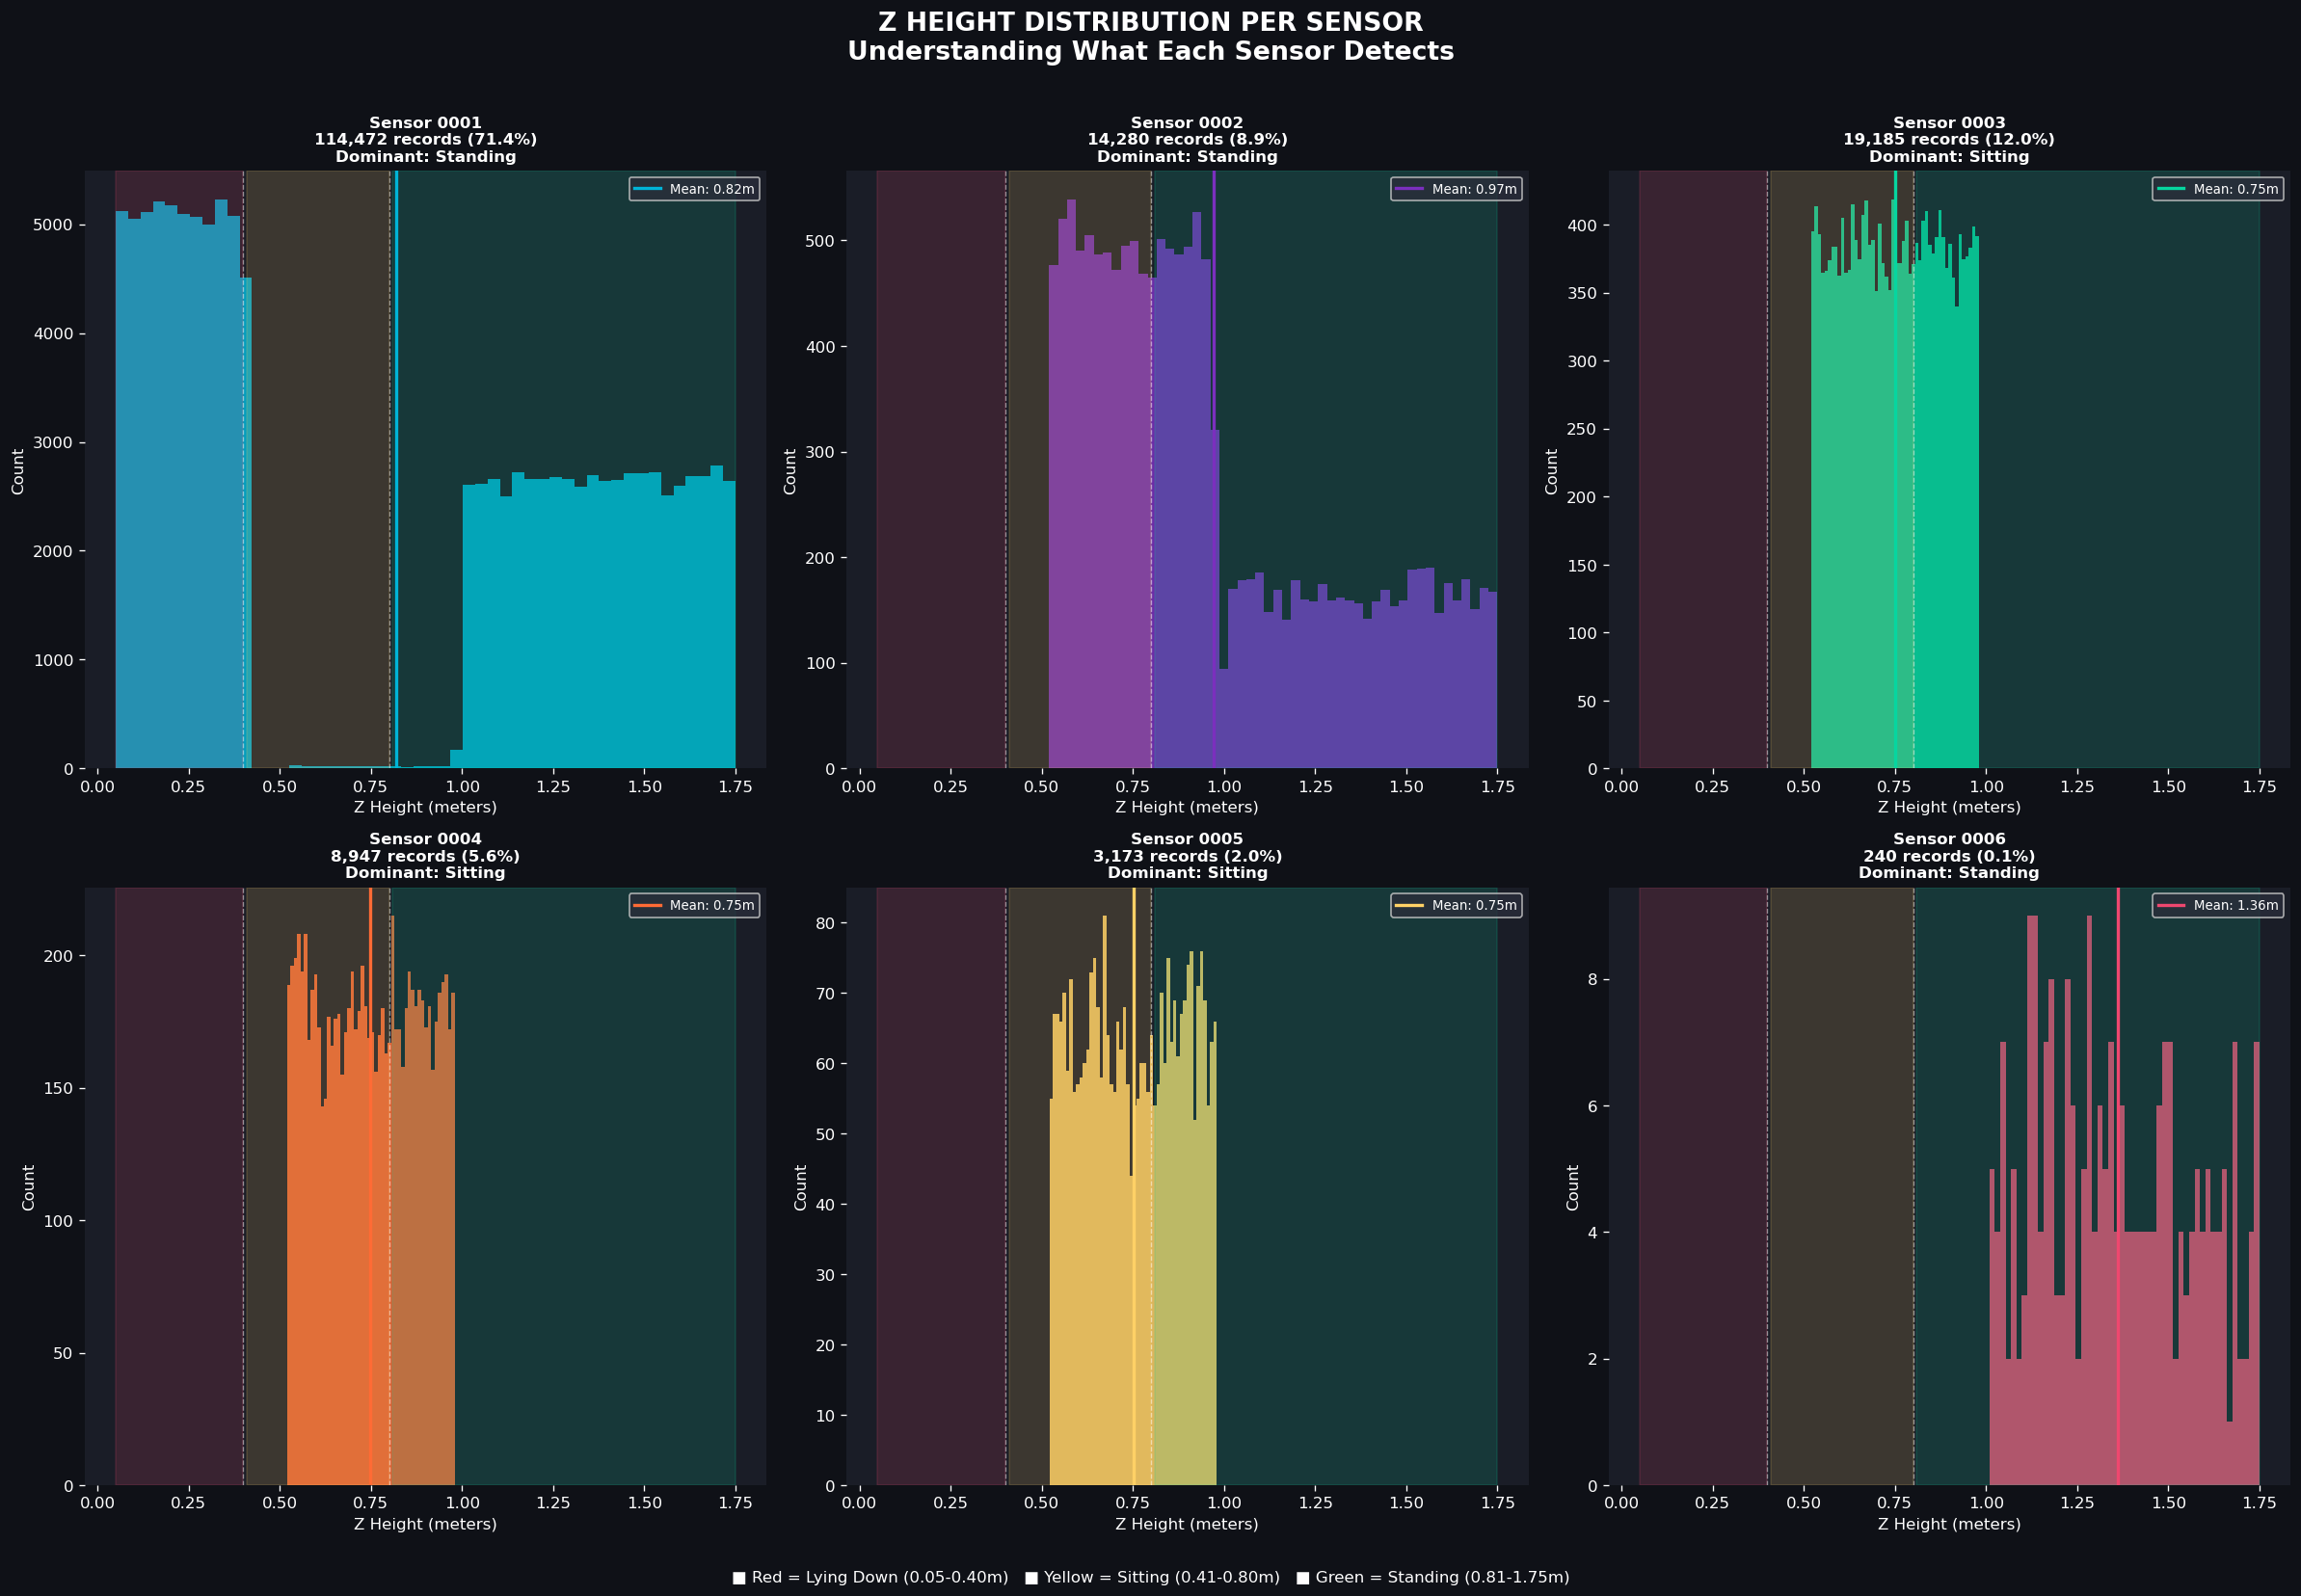

FINDING: Each sensor detects different postures
→ Sensor 0006 (Hallway): only standing detected
→ Sensor 0001 (main area): mix of all postures
→ This tells us the physical nature of each room


In [4]:
# ═══════════════════════════════════════════════
# SECTION 2(i) — Z HEIGHT DISTRIBUTION PER SENSOR
# Which sensor shows which posture patterns?
# ═══════════════════════════════════════════════

fig = plt.figure(figsize=(20, 14),
                 facecolor='#0F1117')
fig.suptitle(
    'Z HEIGHT DISTRIBUTION PER SENSOR\n'
    'Understanding What Each Sensor Detects',
    fontsize=16, fontweight='bold',
    color='white', y=0.98)

sensors = sorted(df['sensor_id'].unique())

for idx, sensor in enumerate(sensors):
    ax  = fig.add_subplot(2, 3, idx+1)
    sub = df[df['sensor_id'] == sensor]

    # Z height histogram
    ax.hist(sub['z_height'], bins=50,
            color=SENSOR_COLORS[sensor],
            edgecolor='none', alpha=0.85)

    # Posture zone bands
    ax.axvspan(0.05, 0.40, alpha=0.15,
               color=POSTURE_COLORS['Lying Down'])
    ax.axvspan(0.41, 0.80, alpha=0.15,
               color=POSTURE_COLORS['Sitting'])
    ax.axvspan(0.81, 1.75, alpha=0.15,
               color=POSTURE_COLORS['Standing'])

    # Boundary lines
    ax.axvline(0.40, color='white',
               linestyle='--', linewidth=0.8,
               alpha=0.5)
    ax.axvline(0.80, color='white',
               linestyle='--', linewidth=0.8,
               alpha=0.5)

    # Mean line
    z_mean = sub['z_height'].mean()
    ax.axvline(z_mean,
               color=SENSOR_COLORS[sensor],
               linewidth=2,
               label=f'Mean: {z_mean:.2f}m')

    # Dominant posture
    dom_posture = sub['posture'].value_counts().index[0]
    count       = len(sub)
    pct         = 100 * count / len(df)

    ax.set_facecolor('#1A1D27')
    ax.set_title(f'Sensor {sensor}\n'
                 f'{count:,} records ({pct:.1f}%)\n'
                 f'Dominant: {dom_posture}',
                 color='white', fontsize=10)
    ax.set_xlabel('Z Height (meters)', color='white')
    ax.set_ylabel('Count', color='white')
    ax.tick_params(colors='white')
    ax.legend(fontsize=8,
              facecolor='#2A2D3A',
              labelcolor='white')
    for spine in ax.spines.values():
        spine.set_visible(False)

# Legend for zones
fig.text(0.5, 0.01,
         '■ Red = Lying Down (0.05-0.40m)   '
         '■ Yellow = Sitting (0.41-0.80m)   '
         '■ Green = Standing (0.81-1.75m)',
         ha='center', color='white',
         fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

print('FINDING: Each sensor detects different postures')
print('→ Sensor 0006 (Hallway): only standing detected')
print('→ Sensor 0001 (main area): mix of all postures')
print('→ This tells us the physical nature of each room')

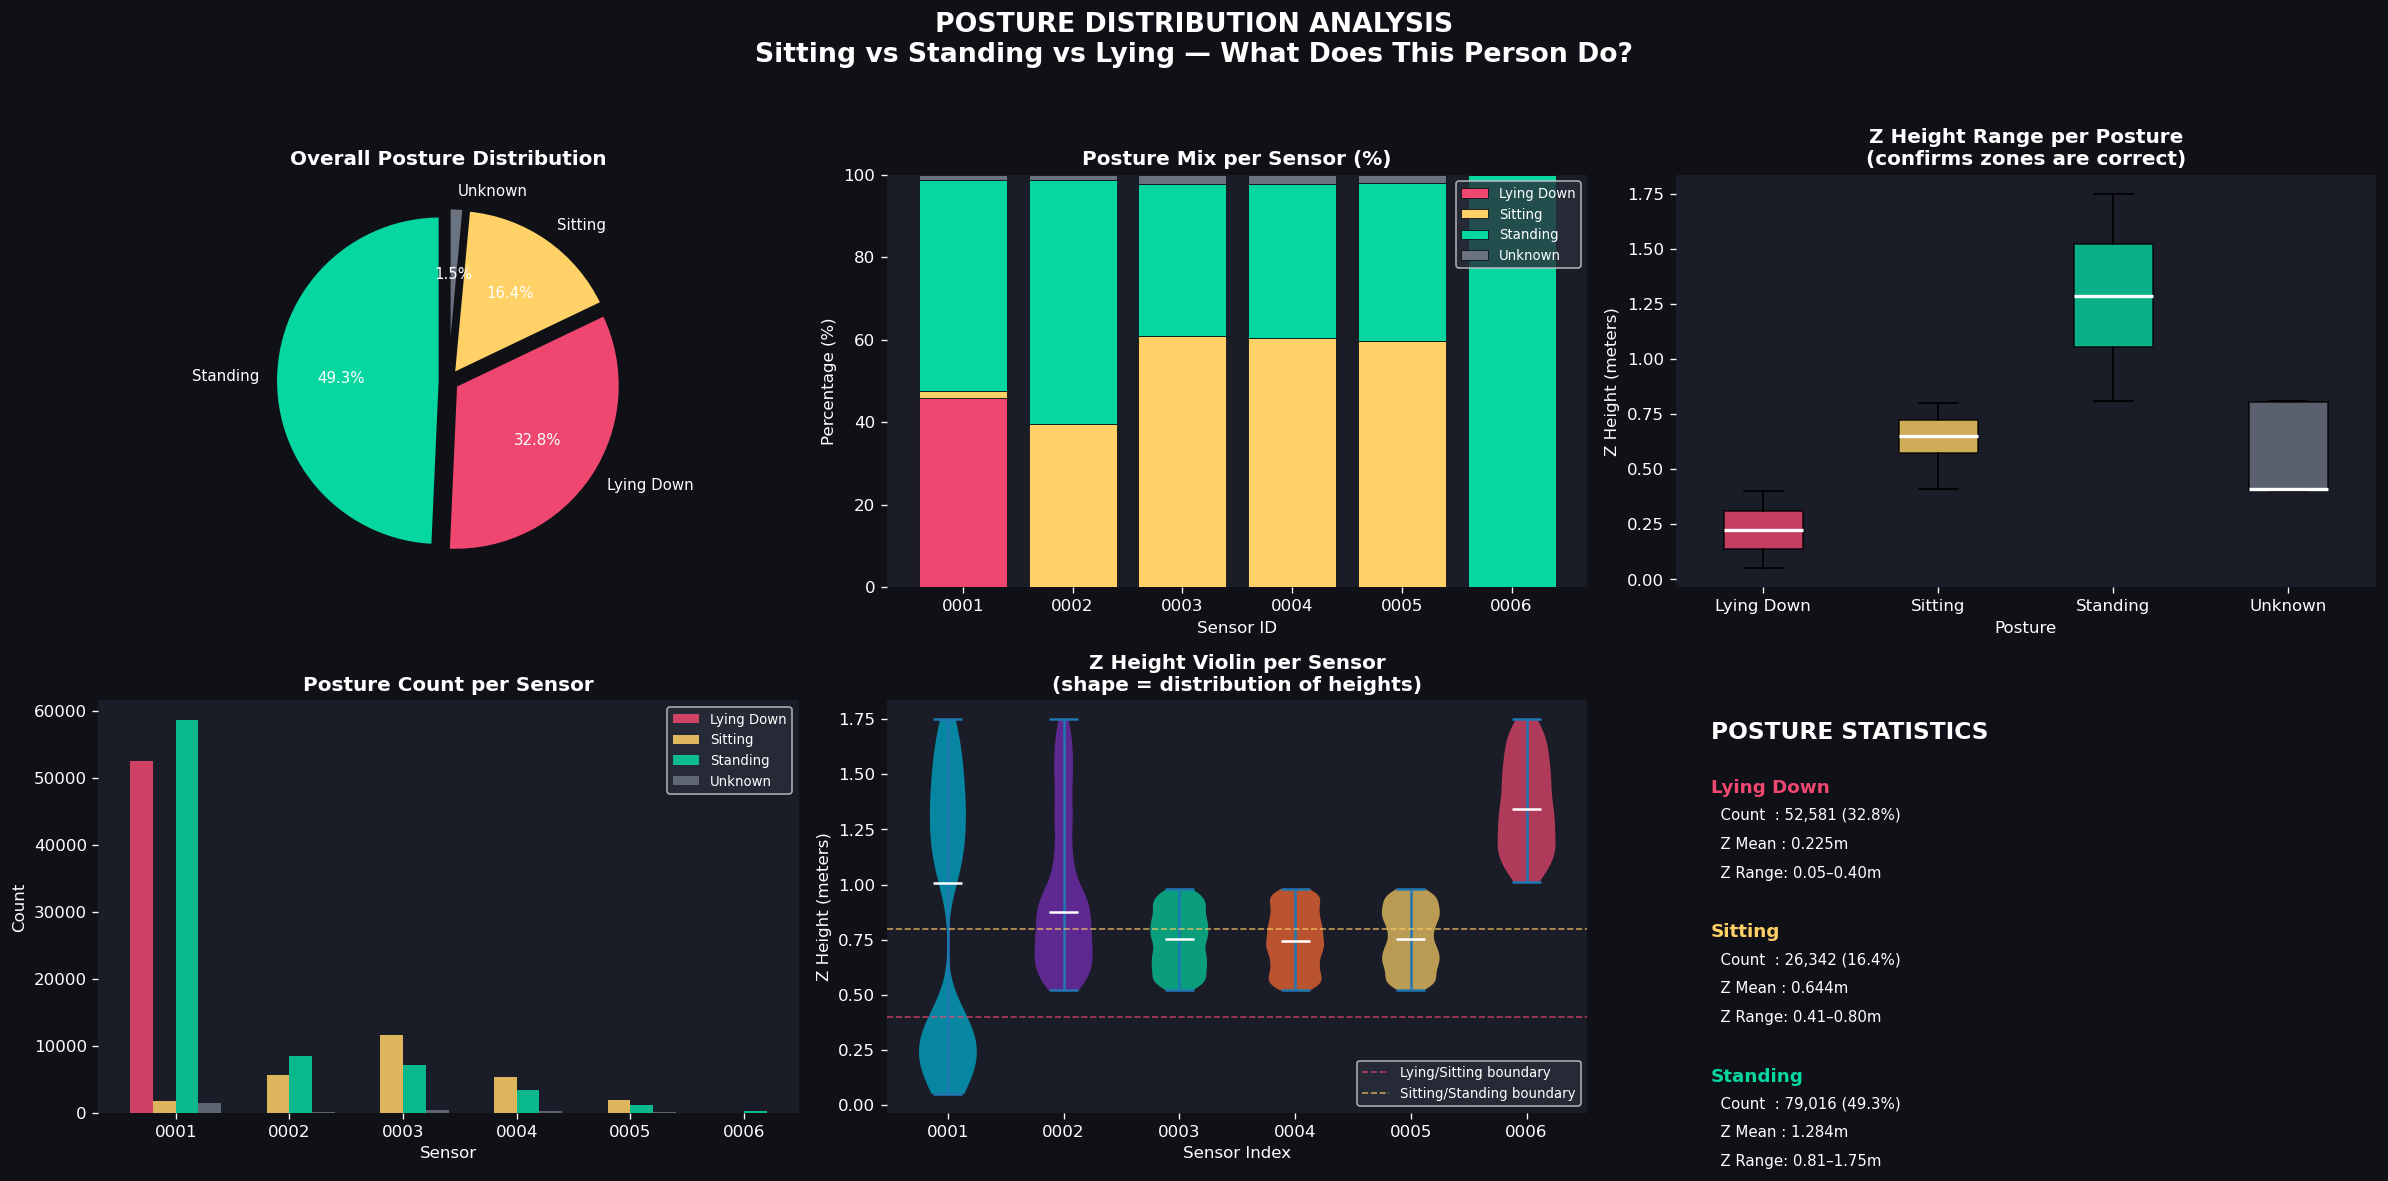

In [5]:
# ═══════════════════════════════════════════════
# SECTION 2(ii) — POSTURE LABEL DISTRIBUTION
# What is the person doing most of the time?
# ═══════════════════════════════════════════════

fig = plt.figure(figsize=(20, 10),
                 facecolor='#0F1117')
fig.suptitle(
    'POSTURE DISTRIBUTION ANALYSIS\n'
    'Sitting vs Standing vs Lying — '
    'What Does This Person Do?',
    fontsize=16, fontweight='bold',
    color='white', y=0.98)

# ── Plot 1: Overall posture pie ─────────────────
ax1 = fig.add_subplot(2, 3, 1)
posture_counts = df['posture'].value_counts()
wedges, texts, autotexts = ax1.pie(
    posture_counts.values,
    labels=posture_counts.index,
    colors=[POSTURE_COLORS[p]
            for p in posture_counts.index],
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.05]*len(posture_counts),
    wedgeprops={'linewidth': 2,
                'edgecolor': '#0F1117'})
for text in texts + autotexts:
    text.set_color('white')
    text.set_fontsize(9)
ax1.set_facecolor('#0F1117')
ax1.set_title('Overall Posture Distribution',
              color='white')

# ── Plot 2: Posture per sensor bar ─────────────
ax2 = fig.add_subplot(2, 3, 2)
posture_sensor = df.groupby(
    ['sensor_id', 'posture']).size().reset_index(
    name='count')
posture_pivot = posture_sensor.pivot(
    index='sensor_id',
    columns='posture',
    values='count').fillna(0)

# Normalize to percentage
posture_pct = posture_pivot.div(
    posture_pivot.sum(axis=1), axis=0) * 100

bottom = np.zeros(len(posture_pct))
for posture in ['Lying Down', 'Sitting',
                'Standing', 'Unknown']:
    if posture in posture_pct.columns:
        ax2.bar(posture_pct.index,
                posture_pct[posture],
                bottom=bottom,
                color=POSTURE_COLORS[posture],
                label=posture,
                edgecolor='#0F1117',
                linewidth=0.5)
        bottom += posture_pct[posture].values

ax2.set_facecolor('#1A1D27')
ax2.set_title('Posture Mix per Sensor (%)',
              color='white')
ax2.set_xlabel('Sensor ID', color='white')
ax2.set_ylabel('Percentage (%)', color='white')
ax2.tick_params(colors='white')
ax2.legend(fontsize=8,
           facecolor='#2A2D3A',
           labelcolor='white',
           loc='upper right')
for spine in ax2.spines.values():
    spine.set_visible(False)

# ── Plot 3: Z height box per posture ───────────
ax3 = fig.add_subplot(2, 3, 3)
posture_order = ['Lying Down', 'Sitting',
                 'Standing', 'Unknown']
data_to_plot  = [
    df[df['posture'] == p]['z_height'].values
    for p in posture_order
    if p in df['posture'].unique()
]
bp = ax3.boxplot(
    data_to_plot,
    labels=[p for p in posture_order
            if p in df['posture'].unique()],
    patch_artist=True,
    medianprops={'color': 'white',
                 'linewidth': 2})
for patch, posture in zip(
        bp['boxes'],
        [p for p in posture_order
         if p in df['posture'].unique()]):
    patch.set_facecolor(POSTURE_COLORS[posture])
    patch.set_alpha(0.8)
ax3.set_facecolor('#1A1D27')
ax3.set_title('Z Height Range per Posture\n'
              '(confirms zones are correct)',
              color='white')
ax3.set_xlabel('Posture', color='white')
ax3.set_ylabel('Z Height (meters)', color='white')
ax3.tick_params(colors='white')
for spine in ax3.spines.values():
    spine.set_visible(False)

# ── Plot 4: Posture count per sensor bars ──────
ax4 = fig.add_subplot(2, 3, 4)
for i, posture in enumerate(
        ['Lying Down','Sitting','Standing','Unknown']):
    sub = posture_sensor[
        posture_sensor['posture'] == posture]
    ax4.bar(
        [x + i*0.2 for x in
         range(len(sub['sensor_id'].unique()))],
        sub['count'].values,
        width=0.2,
        color=POSTURE_COLORS[posture],
        label=posture,
        alpha=0.85)
ax4.set_facecolor('#1A1D27')
ax4.set_title('Posture Count per Sensor',
              color='white')
ax4.set_xlabel('Sensor', color='white')
ax4.set_ylabel('Count', color='white')
ax4.set_xticks([x + 0.3
                for x in range(
                    len(df['sensor_id'].unique()))])
ax4.set_xticklabels(
    sorted(df['sensor_id'].unique()))
ax4.tick_params(colors='white')
ax4.legend(fontsize=8,
           facecolor='#2A2D3A',
           labelcolor='white')
for spine in ax4.spines.values():
    spine.set_visible(False)

# ── Plot 5: Z height violin per sensor ─────────
ax5 = fig.add_subplot(2, 3, 5)
sample = []
for s in df['sensor_id'].unique():
    sub = df[df['sensor_id']==s]
    sample.append(sub.sample(
        min(len(sub), 2000), random_state=42))
sample = pd.concat(sample)

parts = ax5.violinplot(
    [sample[sample['sensor_id']==s]['z_height'].values
     for s in sorted(sample['sensor_id'].unique())],
    positions=range(
        len(sample['sensor_id'].unique())),
    showmedians=True)
for i, (pc, sensor) in enumerate(zip(
        parts['bodies'],
        sorted(sample['sensor_id'].unique()))):
    pc.set_facecolor(SENSOR_COLORS[sensor])
    pc.set_alpha(0.7)
parts['cmedians'].set_color('white')

ax5.axhline(0.40, color=POSTURE_COLORS['Lying Down'],
            linestyle='--', linewidth=1,
            alpha=0.7, label='Lying/Sitting boundary')
ax5.axhline(0.80, color=POSTURE_COLORS['Sitting'],
            linestyle='--', linewidth=1,
            alpha=0.7, label='Sitting/Standing boundary')
ax5.set_facecolor('#1A1D27')
ax5.set_title('Z Height Violin per Sensor\n'
              '(shape = distribution of heights)',
              color='white')
ax5.set_xlabel('Sensor Index', color='white')
ax5.set_ylabel('Z Height (meters)', color='white')
ax5.set_xticks(range(
    len(sample['sensor_id'].unique())))
ax5.set_xticklabels(
    sorted(sample['sensor_id'].unique()))
ax5.tick_params(colors='white')
ax5.legend(fontsize=8,
           facecolor='#2A2D3A',
           labelcolor='white')
for spine in ax5.spines.values():
    spine.set_visible(False)

# ── Plot 6: Posture summary stats ──────────────
ax6 = fig.add_subplot(2, 3, 6)
ax6.set_facecolor('#1A1D27')
ax6.axis('off')

stats_text = [
    ('POSTURE STATISTICS', 'white', 14, True),
    ('', 'white', 10, False),
]
for posture in ['Lying Down','Sitting','Standing']:
    sub   = df[df['posture'] == posture]['z_height']
    count = len(sub)
    pct   = 100 * count / len(df)
    stats_text.append(
        (f'{posture}', POSTURE_COLORS[posture],
         11, True))
    stats_text.append(
        (f'  Count  : {count:,} ({pct:.1f}%)',
         'white', 9, False))
    stats_text.append(
        (f'  Z Mean : {sub.mean():.3f}m',
         'white', 9, False))
    stats_text.append(
        (f'  Z Range: {sub.min():.2f}–'
         f'{sub.max():.2f}m',
         'white', 9, False))
    stats_text.append(('', 'white', 9, False))

y_pos = 0.95
for text, color, size, bold in stats_text:
    weight = 'bold' if bold else 'normal'
    ax6.text(0.05, y_pos, text,
             transform=ax6.transAxes,
             color=color, fontsize=size,
             fontweight=weight,
             verticalalignment='top')
    y_pos -= 0.07

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

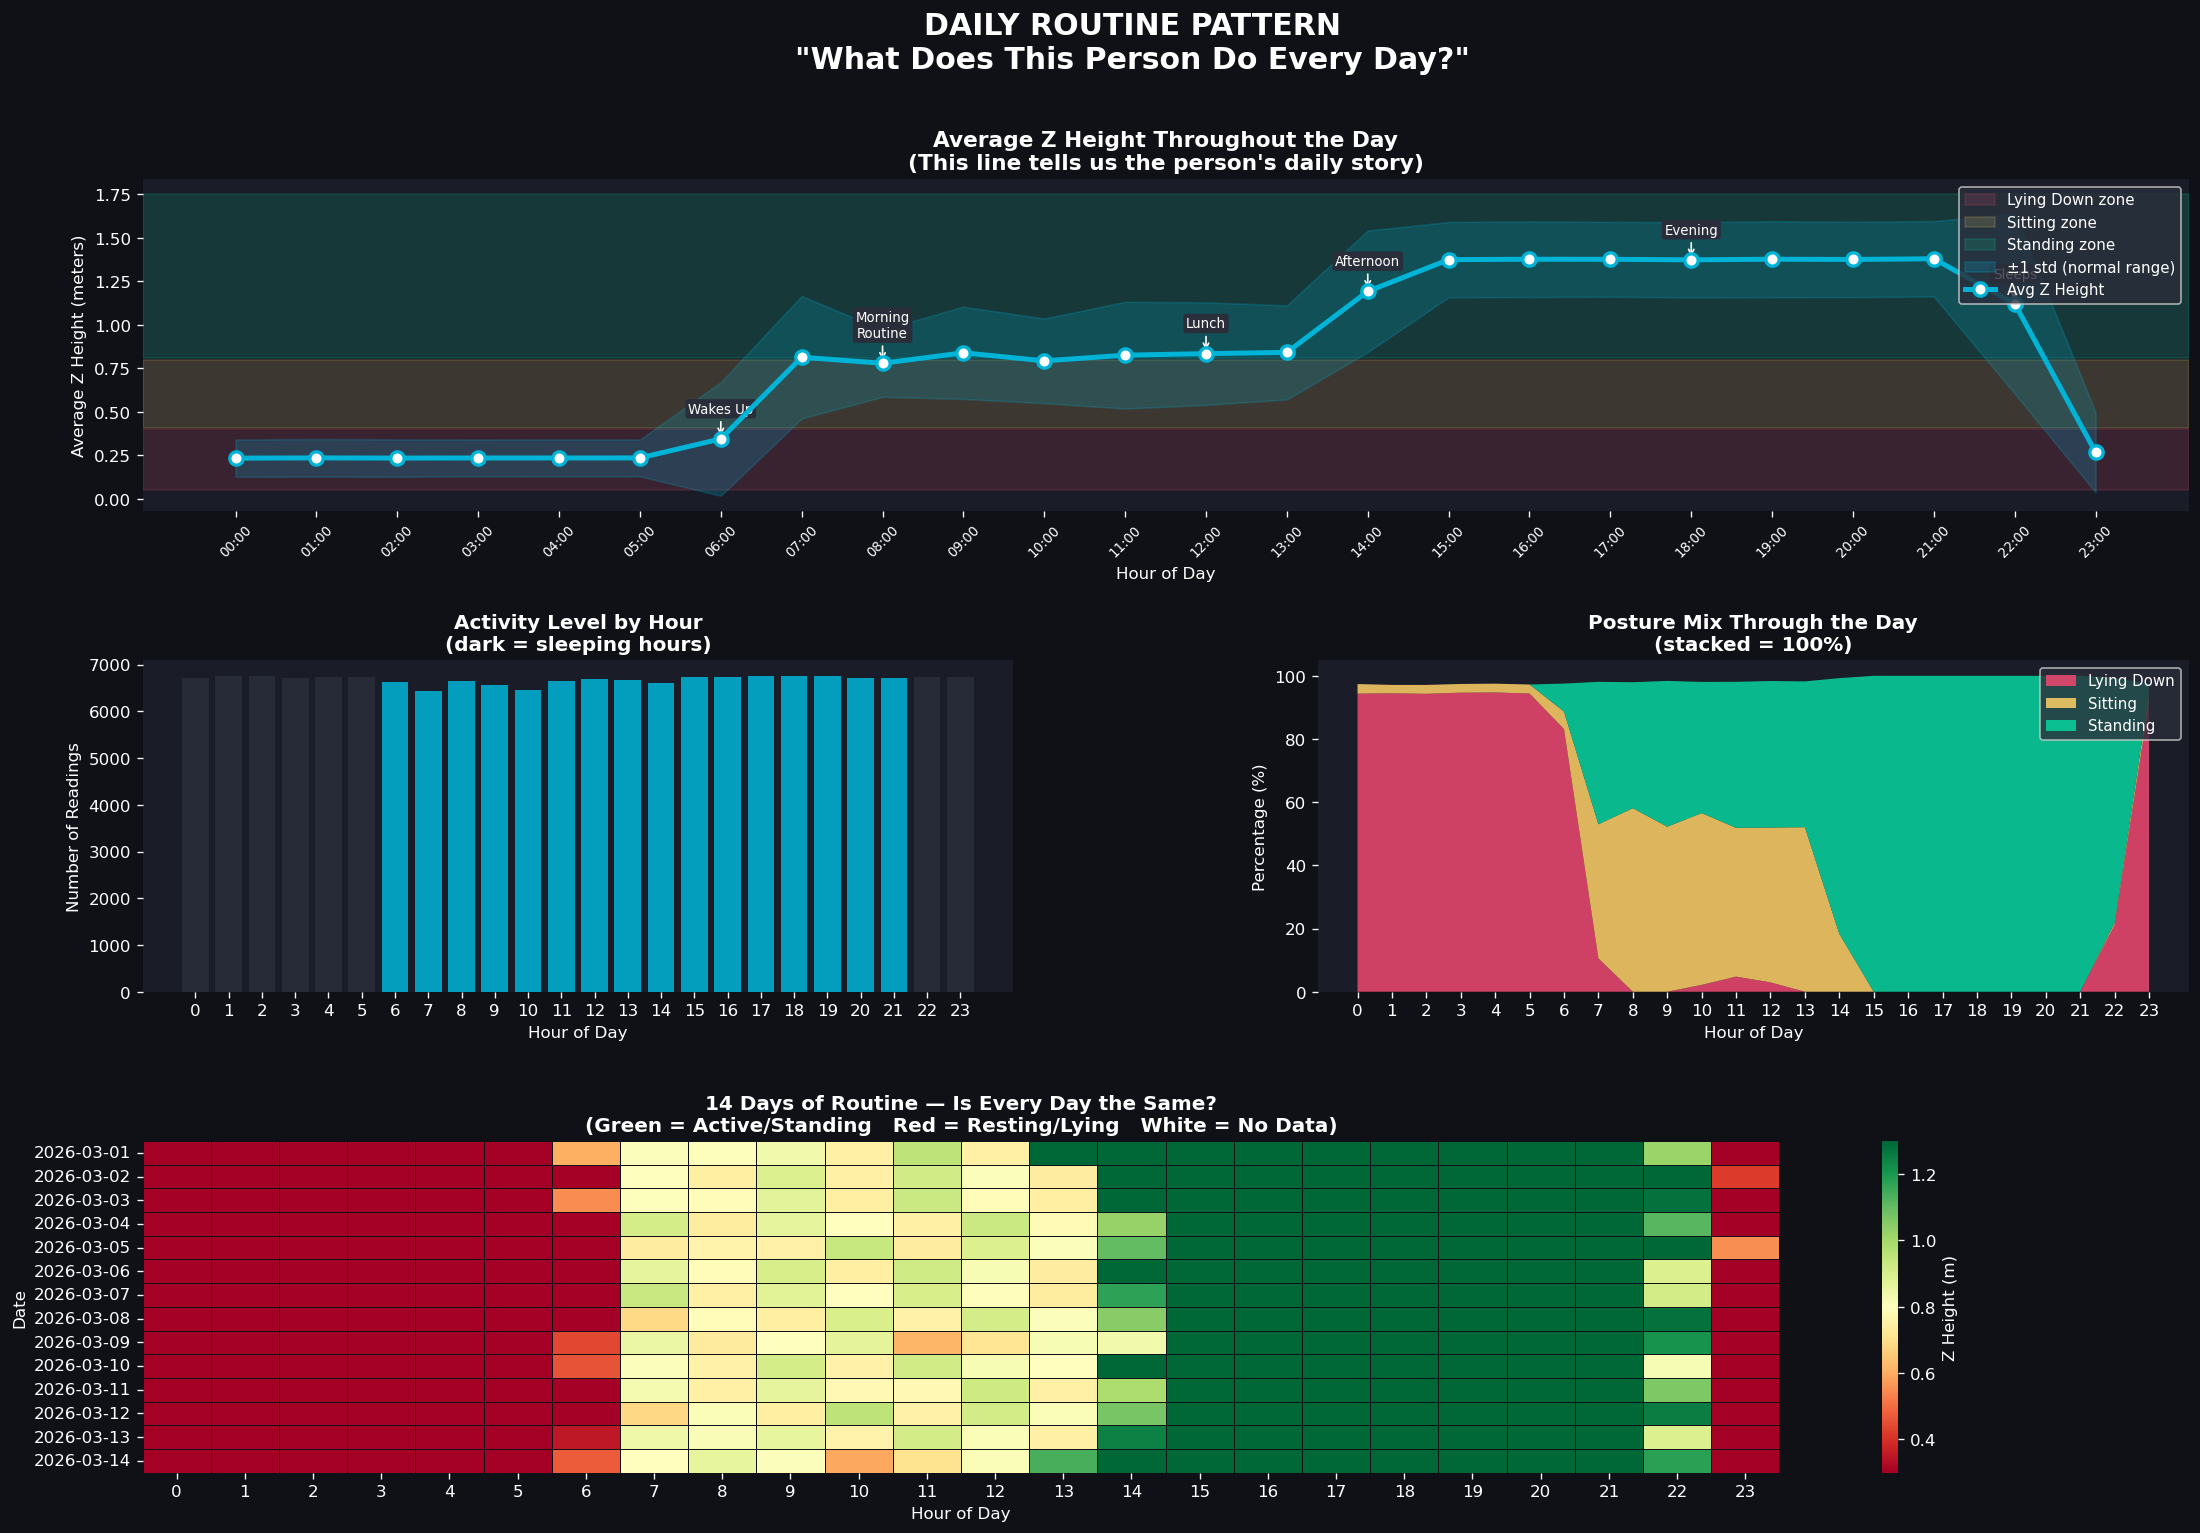

KEY DAILY PATTERN FINDINGS:

Sleeping hours (lowest activity):
  06:00 → 6,635 readings (avg z=0.34m)
  07:00 → 6,424 readings (avg z=0.81m)
  09:00 → 6,556 readings (avg z=0.84m)
  10:00 → 6,456 readings (avg z=0.79m)
  14:00 → 6,607 readings (avg z=1.19m)

Most active hours:
  01:00 → 6,745 readings (avg z=0.24m)
  02:00 → 6,759 readings (avg z=0.23m)
  17:00 → 6,747 readings (avg z=1.38m)
  18:00 → 6,747 readings (avg z=1.37m)
  19:00 → 6,749 readings (avg z=1.38m)


In [6]:
# ═══════════════════════════════════════════════
# SECTION 2(iii) — DAILY ROUTINE PATTERN
# Waking up, eating, sleeping — from sensor data
# ═══════════════════════════════════════════════

hourly = df.groupby('hour').agg(
    n_readings   = ('z_height',  'count'),
    z_mean       = ('z_height',  'mean'),
    z_std        = ('z_height',  'std'),
    lying_pct    = ('posture',
        lambda x: 100*(x=='Lying Down').sum()/len(x)),
    sitting_pct  = ('posture',
        lambda x: 100*(x=='Sitting').sum()/len(x)),
    standing_pct = ('posture',
        lambda x: 100*(x=='Standing').sum()/len(x))
).reset_index()

fig = plt.figure(figsize=(22, 14),
                 facecolor='#0F1117')
fig.suptitle(
    'DAILY ROUTINE PATTERN\n'
    '"What Does This Person Do Every Day?"',
    fontsize=18, fontweight='bold',
    color='white', y=0.98)

gs = gridspec.GridSpec(
    3, 2, figure=fig,
    hspace=0.45, wspace=0.35)

# ── Plot 1: Z height line through the day ──────
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor('#1A1D27')

# Posture zones
ax1.axhspan(0.05, 0.40, alpha=0.15,
            color=POSTURE_COLORS['Lying Down'],
            label='Lying Down zone')
ax1.axhspan(0.41, 0.80, alpha=0.15,
            color=POSTURE_COLORS['Sitting'],
            label='Sitting zone')
ax1.axhspan(0.81, 1.75, alpha=0.15,
            color=POSTURE_COLORS['Standing'],
            label='Standing zone')

# Confidence band
ax1.fill_between(
    hourly['hour'],
    hourly['z_mean'] - hourly['z_std'],
    hourly['z_mean'] + hourly['z_std'],
    alpha=0.2, color='#00B4D8',
    label='±1 std (normal range)')

# Mean line
ax1.plot(hourly['hour'], hourly['z_mean'],
         color='#00B4D8', linewidth=3,
         marker='o', markersize=8,
         markerfacecolor='white',
         markeredgecolor='#00B4D8',
         markeredgewidth=2,
         label='Avg Z Height', zorder=5)

# Annotate key moments
annotations = {
    6  : ('Wakes Up', 0.02),
    8  : ('Morning\nRoutine', 0.02),
    12 : ('Lunch', 0.02),
    14 : ('Afternoon', 0.02),
    18 : ('Evening', 0.02),
    22 : ('Sleeps', 0.02)
}
for hour, (label, offset) in annotations.items():
    if hour in hourly['hour'].values:
        z_val = hourly[
            hourly['hour']==hour]['z_mean'].values[0]
        ax1.annotate(
            label,
            xy=(hour, z_val),
            xytext=(hour, z_val + 0.15),
            color='white', fontsize=8,
            ha='center',
            arrowprops=dict(
                arrowstyle='->', color='white',
                lw=1),
            bbox=dict(
                boxstyle='round,pad=0.2',
                facecolor='#2A2D3A',
                edgecolor='none'))

ax1.set_title(
    'Average Z Height Throughout the Day\n'
    '(This line tells us the person\'s daily story)',
    color='white', fontsize=13)
ax1.set_xlabel('Hour of Day', color='white')
ax1.set_ylabel('Average Z Height (meters)',
               color='white')
ax1.set_xticks(range(0, 24))
ax1.set_xticklabels(
    [f'{h:02d}:00' for h in range(24)],
    rotation=45, fontsize=8)
ax1.tick_params(colors='white')
ax1.legend(fontsize=9,
           facecolor='#2A2D3A',
           labelcolor='white',
           loc='upper right')
for spine in ax1.spines.values():
    spine.set_visible(False)

# ── Plot 2: Activity level by hour ─────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor('#1A1D27')

colors_bar = ['#2A2D3A'
               if h in [0,1,2,3,4,5,22,23]
               else '#00B4D8'
               for h in hourly['hour']]
bars = ax2.bar(hourly['hour'],
               hourly['n_readings'],
               color=colors_bar,
               alpha=0.85,
               edgecolor='none')
ax2.set_title('Activity Level by Hour\n'
              '(dark = sleeping hours)',
              color='white')
ax2.set_xlabel('Hour of Day', color='white')
ax2.set_ylabel('Number of Readings', color='white')
ax2.set_xticks(range(0, 24))
ax2.tick_params(colors='white')
for spine in ax2.spines.values():
    spine.set_visible(False)

# ── Plot 3: Stacked posture through day ────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor('#1A1D27')

ax3.stackplot(
    hourly['hour'],
    hourly['lying_pct'],
    hourly['sitting_pct'],
    hourly['standing_pct'],
    labels=['Lying Down', 'Sitting', 'Standing'],
    colors=[POSTURE_COLORS['Lying Down'],
            POSTURE_COLORS['Sitting'],
            POSTURE_COLORS['Standing']],
    alpha=0.85)
ax3.set_title('Posture Mix Through the Day\n'
              '(stacked = 100%)',
              color='white')
ax3.set_xlabel('Hour of Day', color='white')
ax3.set_ylabel('Percentage (%)', color='white')
ax3.set_xticks(range(0, 24))
ax3.tick_params(colors='white')
ax3.legend(fontsize=9,
           facecolor='#2A2D3A',
           labelcolor='white',
           loc='upper right')
for spine in ax3.spines.values():
    spine.set_visible(False)

# ── Plot 4: Day by day heatmap ─────────────────
ax4 = fig.add_subplot(gs[2, :])
ax4.set_facecolor('#1A1D27')

daily_hour = df.groupby(
    ['date', 'hour'])['z_height'].mean().reset_index()
daily_pivot = daily_hour.pivot(
    index='date', columns='hour',
    values='z_height').ffill(axis=1)

sns.heatmap(
    daily_pivot,
    cmap='RdYlGn',
    vmin=0.3, vmax=1.3,
    linewidths=0.3,
    linecolor='#0F1117',
    ax=ax4,
    cbar_kws={'label': 'Z Height (m)'})
ax4.set_title(
    '14 Days of Routine — '
    'Is Every Day the Same?\n'
    '(Green = Active/Standing   '
    'Red = Resting/Lying   '
    'White = No Data)',
    color='white')
ax4.set_xlabel('Hour of Day', color='white')
ax4.set_ylabel('Date', color='white')
ax4.tick_params(colors='white')

plt.savefig('eda_daily_pattern.png',
            dpi=150, bbox_inches='tight',
            facecolor='#0F1117')
plt.show()

# Print key findings
print('KEY DAILY PATTERN FINDINGS:')
print()
print('Sleeping hours (lowest activity):')
bottom5 = hourly.nsmallest(5,'n_readings')
for _, r in bottom5.sort_values('hour').iterrows():
    print(f'  {int(r["hour"]):02d}:00 → '
          f'{int(r["n_readings"]):,} readings '
          f'(avg z={r["z_mean"]:.2f}m)')
print()
print('Most active hours:')
top5 = hourly.nlargest(5,'n_readings')
for _, r in top5.sort_values('hour').iterrows():
    print(f'  {int(r["hour"]):02d}:00 → '
          f'{int(r["n_readings"]):,} readings '
          f'(avg z={r["z_mean"]:.2f}m)')

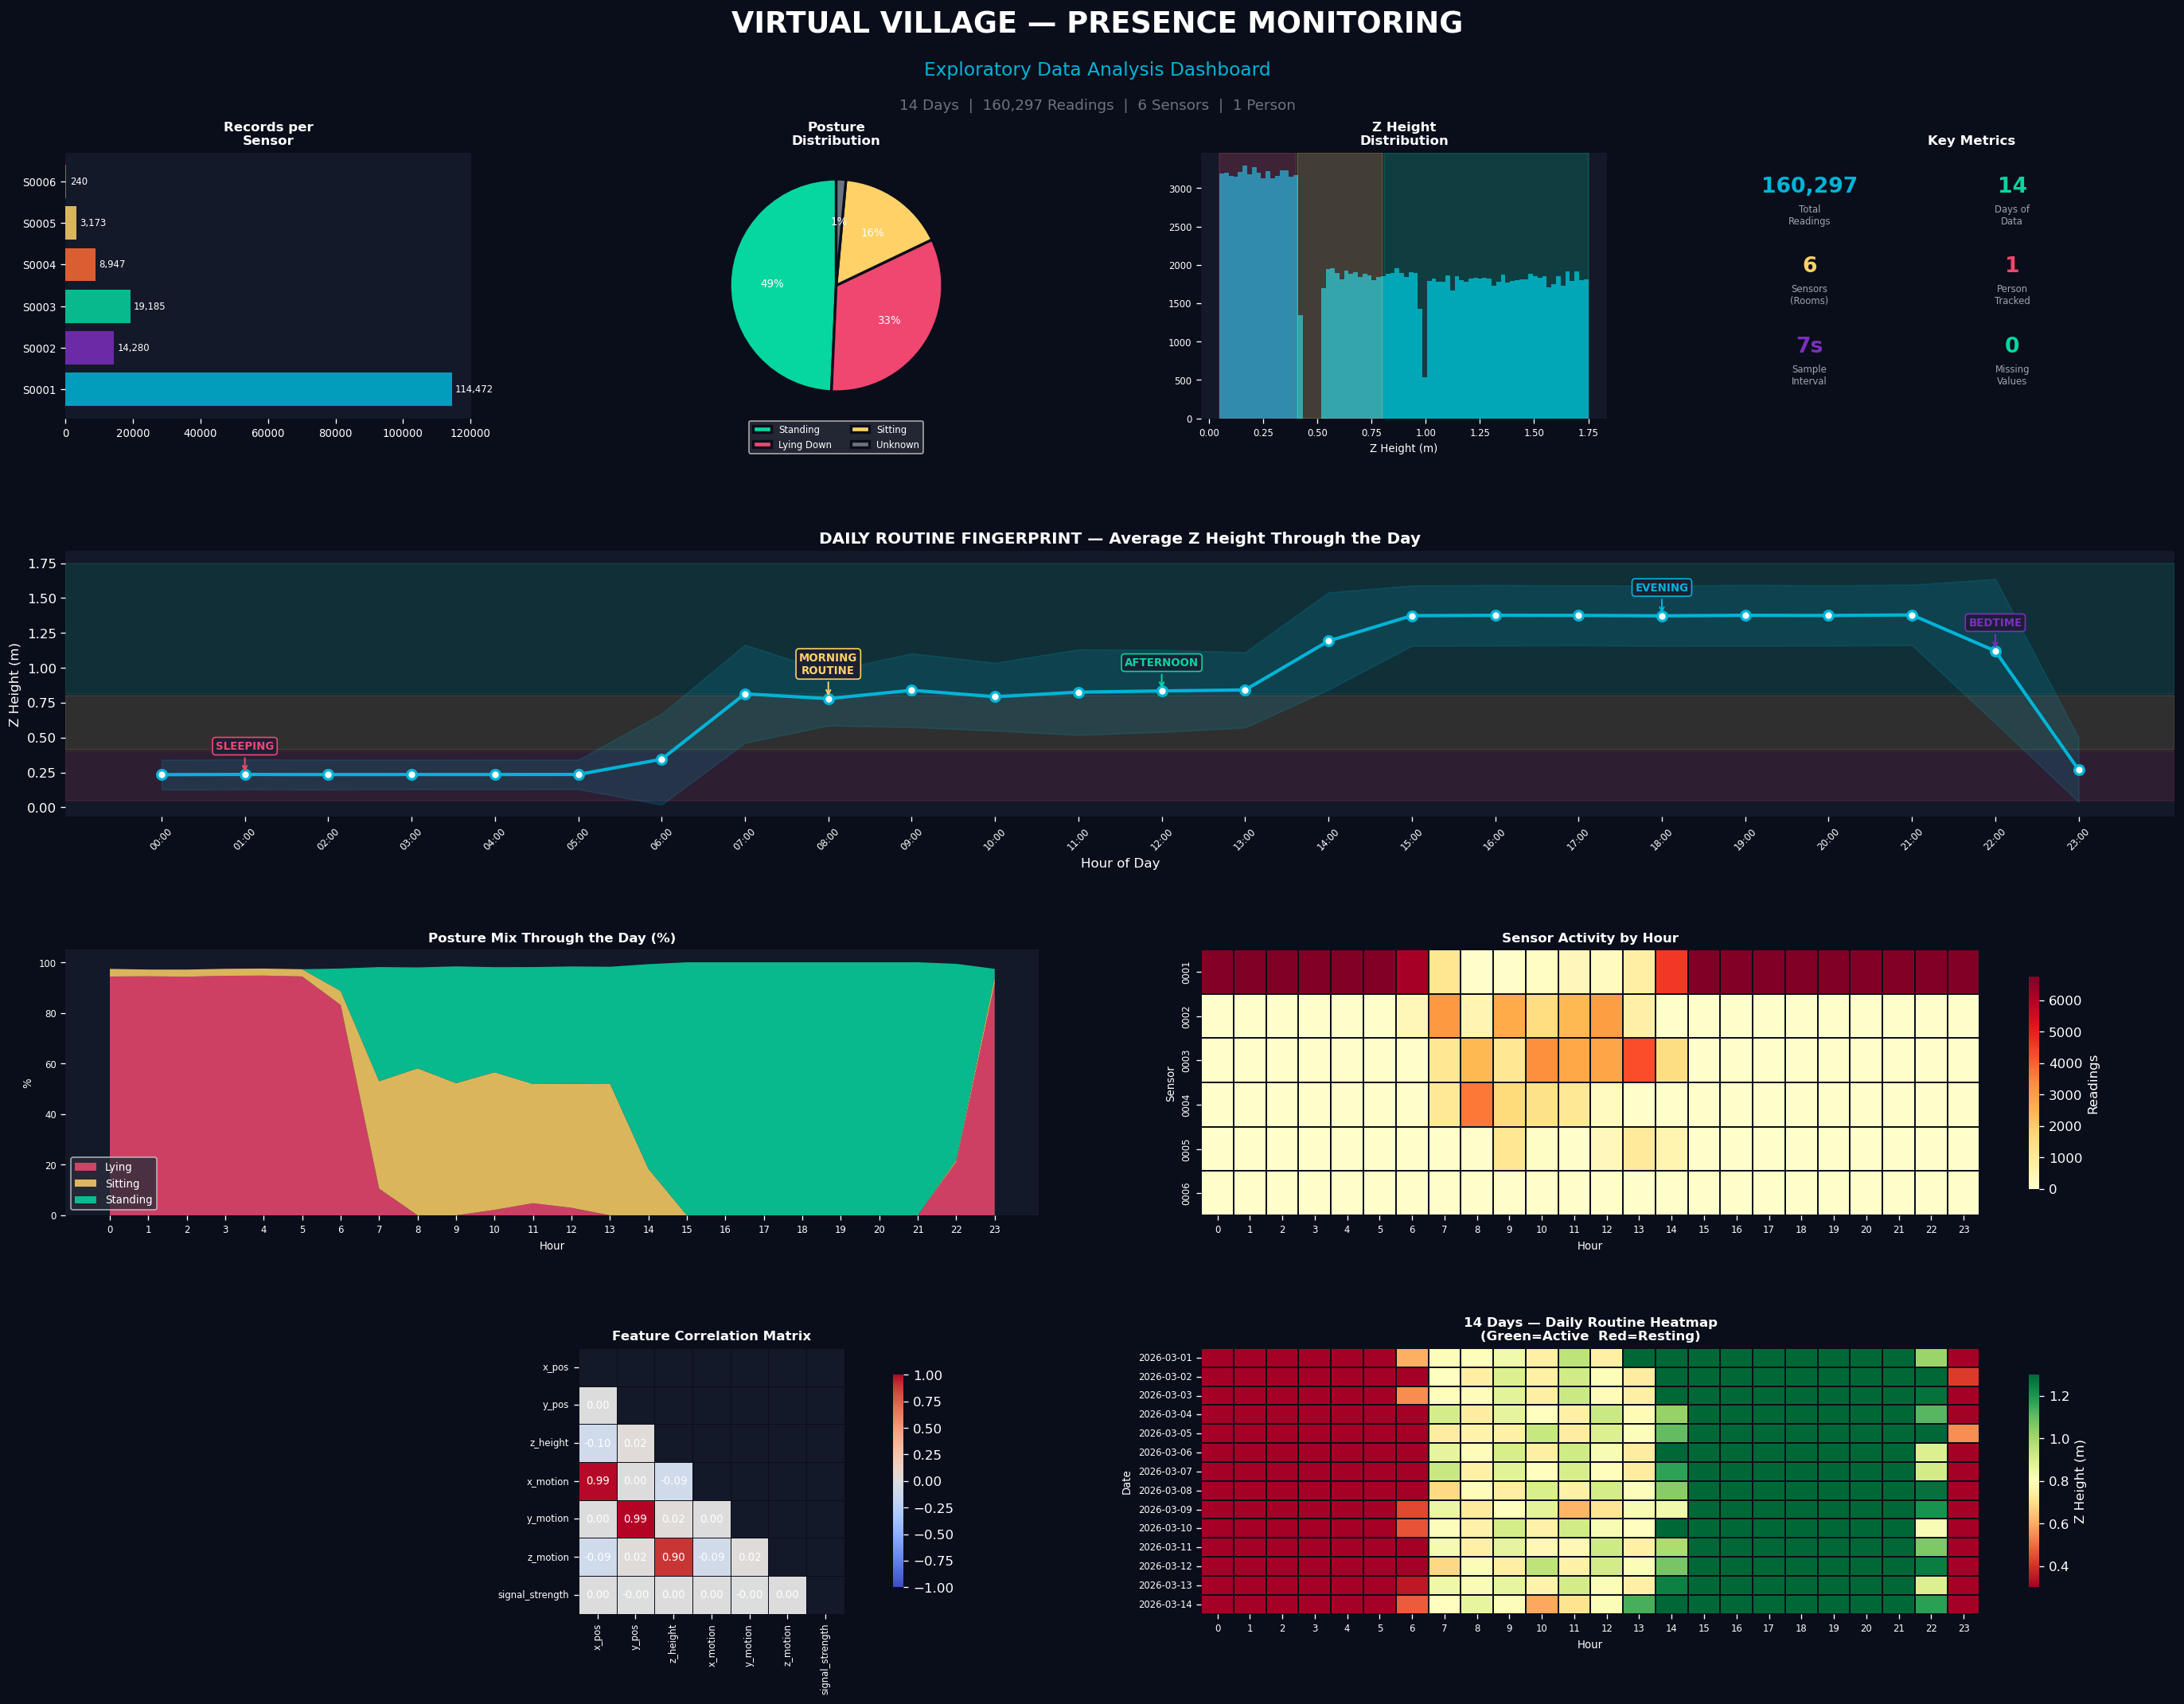

✓ Dashboard saved as eda_master_dashboard.png


In [7]:
# ═══════════════════════════════════════════════
# SECTION 2(v) — MASTER EDA DASHBOARD
# Everything in one stunning visualization
# ═══════════════════════════════════════════════

fig = plt.figure(figsize=(24, 18),
                 facecolor='#0A0E1A')

# Title
fig.text(0.5, 0.97,
         'VIRTUAL VILLAGE — PRESENCE MONITORING',
         ha='center', color='white',
         fontsize=22, fontweight='bold')
fig.text(0.5, 0.945,
         'Exploratory Data Analysis Dashboard',
         ha='center', color='#00B4D8',
         fontsize=14)
fig.text(0.5, 0.925,
         f'14 Days  |  {len(df):,} Readings  |  '
         f'6 Sensors  |  1 Person',
         ha='center', color='#6B7280',
         fontsize=11)

gs = gridspec.GridSpec(
    4, 4, figure=fig,
    hspace=0.5, wspace=0.4,
    top=0.90, bottom=0.05,
    left=0.05, right=0.97)

# ── Panel 1: Sensor records bar ─────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#131929')
sensor_counts = df['sensor_id'].value_counts(
    ).sort_index()
bars = ax1.barh(
    [f'S{s}' for s in sensor_counts.index],
    sensor_counts.values,
    color=[SENSOR_COLORS[s]
           for s in sensor_counts.index],
    alpha=0.85, edgecolor='none')
for bar, val in zip(bars, sensor_counts.values):
    ax1.text(val + 1000, bar.get_y() +
             bar.get_height()/2,
             f'{val:,}',
             va='center', color='white',
             fontsize=7)
ax1.set_title('Records per\nSensor',
              color='white', fontsize=10)
ax1.tick_params(colors='white', labelsize=8)
for spine in ax1.spines.values():
    spine.set_visible(False)

# ── Panel 2: Posture pie ────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#131929')
posture_counts = df['posture'].value_counts()
wedges, _, autotexts = ax2.pie(
    posture_counts.values,
    colors=[POSTURE_COLORS[p]
            for p in posture_counts.index],
    autopct='%1.0f%%',
    startangle=90,
    wedgeprops={'linewidth':2,
                'edgecolor':'#0A0E1A'})
for at in autotexts:
    at.set_color('white')
    at.set_fontsize(8)
ax2.set_title('Posture\nDistribution',
              color='white', fontsize=10)
ax2.legend(
    wedges, posture_counts.index,
    loc='lower center',
    fontsize=7,
    facecolor='#2A2D3A',
    labelcolor='white',
    ncol=2,
    bbox_to_anchor=(0.5, -0.15))

# ── Panel 3: Z height overall dist ─────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor('#131929')
ax3.hist(df['z_height'], bins=80,
         color='#00B4D8',
         edgecolor='none', alpha=0.85)
ax3.axvspan(0.05, 0.40, alpha=0.2,
            color=POSTURE_COLORS['Lying Down'])
ax3.axvspan(0.41, 0.80, alpha=0.2,
            color=POSTURE_COLORS['Sitting'])
ax3.axvspan(0.81, 1.75, alpha=0.2,
            color=POSTURE_COLORS['Standing'])
ax3.set_title('Z Height\nDistribution',
              color='white', fontsize=10)
ax3.set_xlabel('Z Height (m)',
               color='white', fontsize=8)
ax3.tick_params(colors='white', labelsize=7)
for spine in ax3.spines.values():
    spine.set_visible(False)

# ── Panel 4: KPI stats box ──────────────────────
ax4 = fig.add_subplot(gs[0, 3])
ax4.set_facecolor('#131929')
ax4.axis('off')
kpis = [
    ('160,297', 'Total\nReadings',   '#00B4D8'),
    ('14',      'Days of\nData',     '#06D6A0'),
    ('6',       'Sensors\n(Rooms)',  '#FFD166'),
    ('1',       'Person\nTracked',   '#EF476F'),
    ('7s',      'Sample\nInterval',  '#7B2FBE'),
    ('0',       'Missing\nValues',   '#06D6A0'),
]
positions = [(0.1,0.85),(0.6,0.85),
             (0.1,0.55),(0.6,0.55),
             (0.1,0.25),(0.6,0.25)]
for (val,label,color),(x,y) in zip(kpis,positions):
    ax4.text(x, y, val,
             transform=ax4.transAxes,
             color=color, fontsize=16,
             fontweight='bold',
             ha='center')
    ax4.text(x, y-0.12, label,
             transform=ax4.transAxes,
             color='#9CA3AF', fontsize=7,
             ha='center')
ax4.set_title('Key Metrics',
              color='white', fontsize=10)

# ── Panel 5: Z height line through day ─────────
ax5 = fig.add_subplot(gs[1, :])
ax5.set_facecolor('#131929')

ax5.axhspan(0.05, 0.40, alpha=0.12,
            color=POSTURE_COLORS['Lying Down'])
ax5.axhspan(0.41, 0.80, alpha=0.12,
            color=POSTURE_COLORS['Sitting'])
ax5.axhspan(0.81, 1.75, alpha=0.12,
            color=POSTURE_COLORS['Standing'])

ax5.fill_between(
    hourly['hour'],
    hourly['z_mean'] - hourly['z_std'],
    hourly['z_mean'] + hourly['z_std'],
    alpha=0.15, color='#00B4D8')
ax5.plot(
    hourly['hour'], hourly['z_mean'],
    color='#00B4D8', linewidth=2.5,
    marker='o', markersize=7,
    markerfacecolor='white',
    markeredgecolor='#00B4D8',
    markeredgewidth=2)

# Time period annotations
periods = [
    (1,  'SLEEPING',  '#EF476F'),
    (8,  'MORNING\nROUTINE', '#FFD166'),
    (12, 'AFTERNOON', '#06D6A0'),
    (18, 'EVENING',   '#00B4D8'),
    (22, 'BEDTIME',   '#7B2FBE'),
]
for hour, label, color in periods:
    if hour in hourly['hour'].values:
        z = hourly[hourly['hour']==hour
                   ]['z_mean'].values[0]
        ax5.annotate(
            label,
            xy=(hour, z),
            xytext=(hour, z+0.18),
            color=color, fontsize=8,
            ha='center', fontweight='bold',
            arrowprops=dict(
                arrowstyle='->',
                color=color, lw=1.2),
            bbox=dict(
                boxstyle='round,pad=0.3',
                facecolor='#1A2035',
                edgecolor=color,
                linewidth=1))

ax5.set_title(
    'DAILY ROUTINE FINGERPRINT — '
    'Average Z Height Through the Day',
    color='white', fontsize=12)
ax5.set_xlabel('Hour of Day', color='white')
ax5.set_ylabel('Z Height (m)', color='white')
ax5.set_xticks(range(0,24))
ax5.set_xticklabels(
    [f'{h:02d}:00' for h in range(24)],
    rotation=45, fontsize=7, color='white')
ax5.tick_params(colors='white')
for spine in ax5.spines.values():
    spine.set_visible(False)

# ── Panel 6: Stacked posture by hour ───────────
ax6 = fig.add_subplot(gs[2, :2])
ax6.set_facecolor('#131929')
ax6.stackplot(
    hourly['hour'],
    hourly['lying_pct'],
    hourly['sitting_pct'],
    hourly['standing_pct'],
    colors=[POSTURE_COLORS['Lying Down'],
            POSTURE_COLORS['Sitting'],
            POSTURE_COLORS['Standing']],
    alpha=0.85,
    labels=['Lying','Sitting','Standing'])
ax6.set_title('Posture Mix Through the Day (%)',
              color='white', fontsize=10)
ax6.set_xlabel('Hour', color='white', fontsize=8)
ax6.set_ylabel('%', color='white', fontsize=8)
ax6.set_xticks(range(0,24))
ax6.tick_params(colors='white', labelsize=7)
ax6.legend(fontsize=8,
           facecolor='#2A2D3A',
           labelcolor='white')
for spine in ax6.spines.values():
    spine.set_visible(False)

# ── Panel 7: Room heatmap ───────────────────────
ax7 = fig.add_subplot(gs[2, 2:])
ax7.set_facecolor('#131929')
room_hour = df.groupby(
    ['sensor_id','hour'])['z_height'].count(
    ).reset_index()
room_hour.columns = ['sensor','hour','count']
pivot = room_hour.pivot(
    index='sensor',
    columns='hour',
    values='count').fillna(0)
sns.heatmap(
    pivot, cmap='YlOrRd',
    linewidths=0.2,
    linecolor='#0A0E1A',
    ax=ax7,
    cbar_kws={'shrink':0.8,
              'label':'Readings'})
ax7.set_title('Sensor Activity by Hour',
              color='white', fontsize=10)
ax7.set_xlabel('Hour', color='white', fontsize=8)
ax7.set_ylabel('Sensor', color='white', fontsize=8)
ax7.tick_params(colors='white', labelsize=7)

# ── Panel 8: Correlation heatmap ───────────────
ax8 = fig.add_subplot(gs[3, :2])
ax8.set_facecolor('#131929')
features = ['x_pos','y_pos','z_height',
            'x_motion','y_motion','z_motion',
            'signal_strength']
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, annot=True, fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    mask=mask, square=True,
    linewidths=0.5,
    linecolor='#0A0E1A',
    ax=ax8,
    annot_kws={'size':8,'color':'white'},
    cbar_kws={'shrink':0.8})
ax8.set_title('Feature Correlation Matrix',
              color='white', fontsize=10)
ax8.tick_params(colors='white', labelsize=7)

# ── Panel 9: 14 day heatmap ─────────────────────
ax9 = fig.add_subplot(gs[3, 2:])
ax9.set_facecolor('#131929')
daily_hour = df.groupby(
    ['date','hour'])['z_height'].mean(
    ).reset_index()
daily_pivot = daily_hour.pivot(
    index='date', columns='hour',
    values='z_height').ffill(axis=1)
sns.heatmap(
    daily_pivot,
    cmap='RdYlGn',
    vmin=0.3, vmax=1.3,
    linewidths=0.2,
    linecolor='#0A0E1A',
    ax=ax9,
    cbar_kws={'shrink':0.8,
              'label':'Z Height (m)'})
ax9.set_title('14 Days — Daily Routine Heatmap\n'
              '(Green=Active  Red=Resting)',
              color='white', fontsize=10)
ax9.set_xlabel('Hour', color='white', fontsize=8)
ax9.set_ylabel('Date', color='white', fontsize=8)
ax9.tick_params(colors='white', labelsize=7)

plt.savefig('eda_master_dashboard.png',
            dpi=150,
            bbox_inches='tight',
            facecolor='#0A0E1A')
plt.show()
print('✓ Dashboard saved as eda_master_dashboard.png')

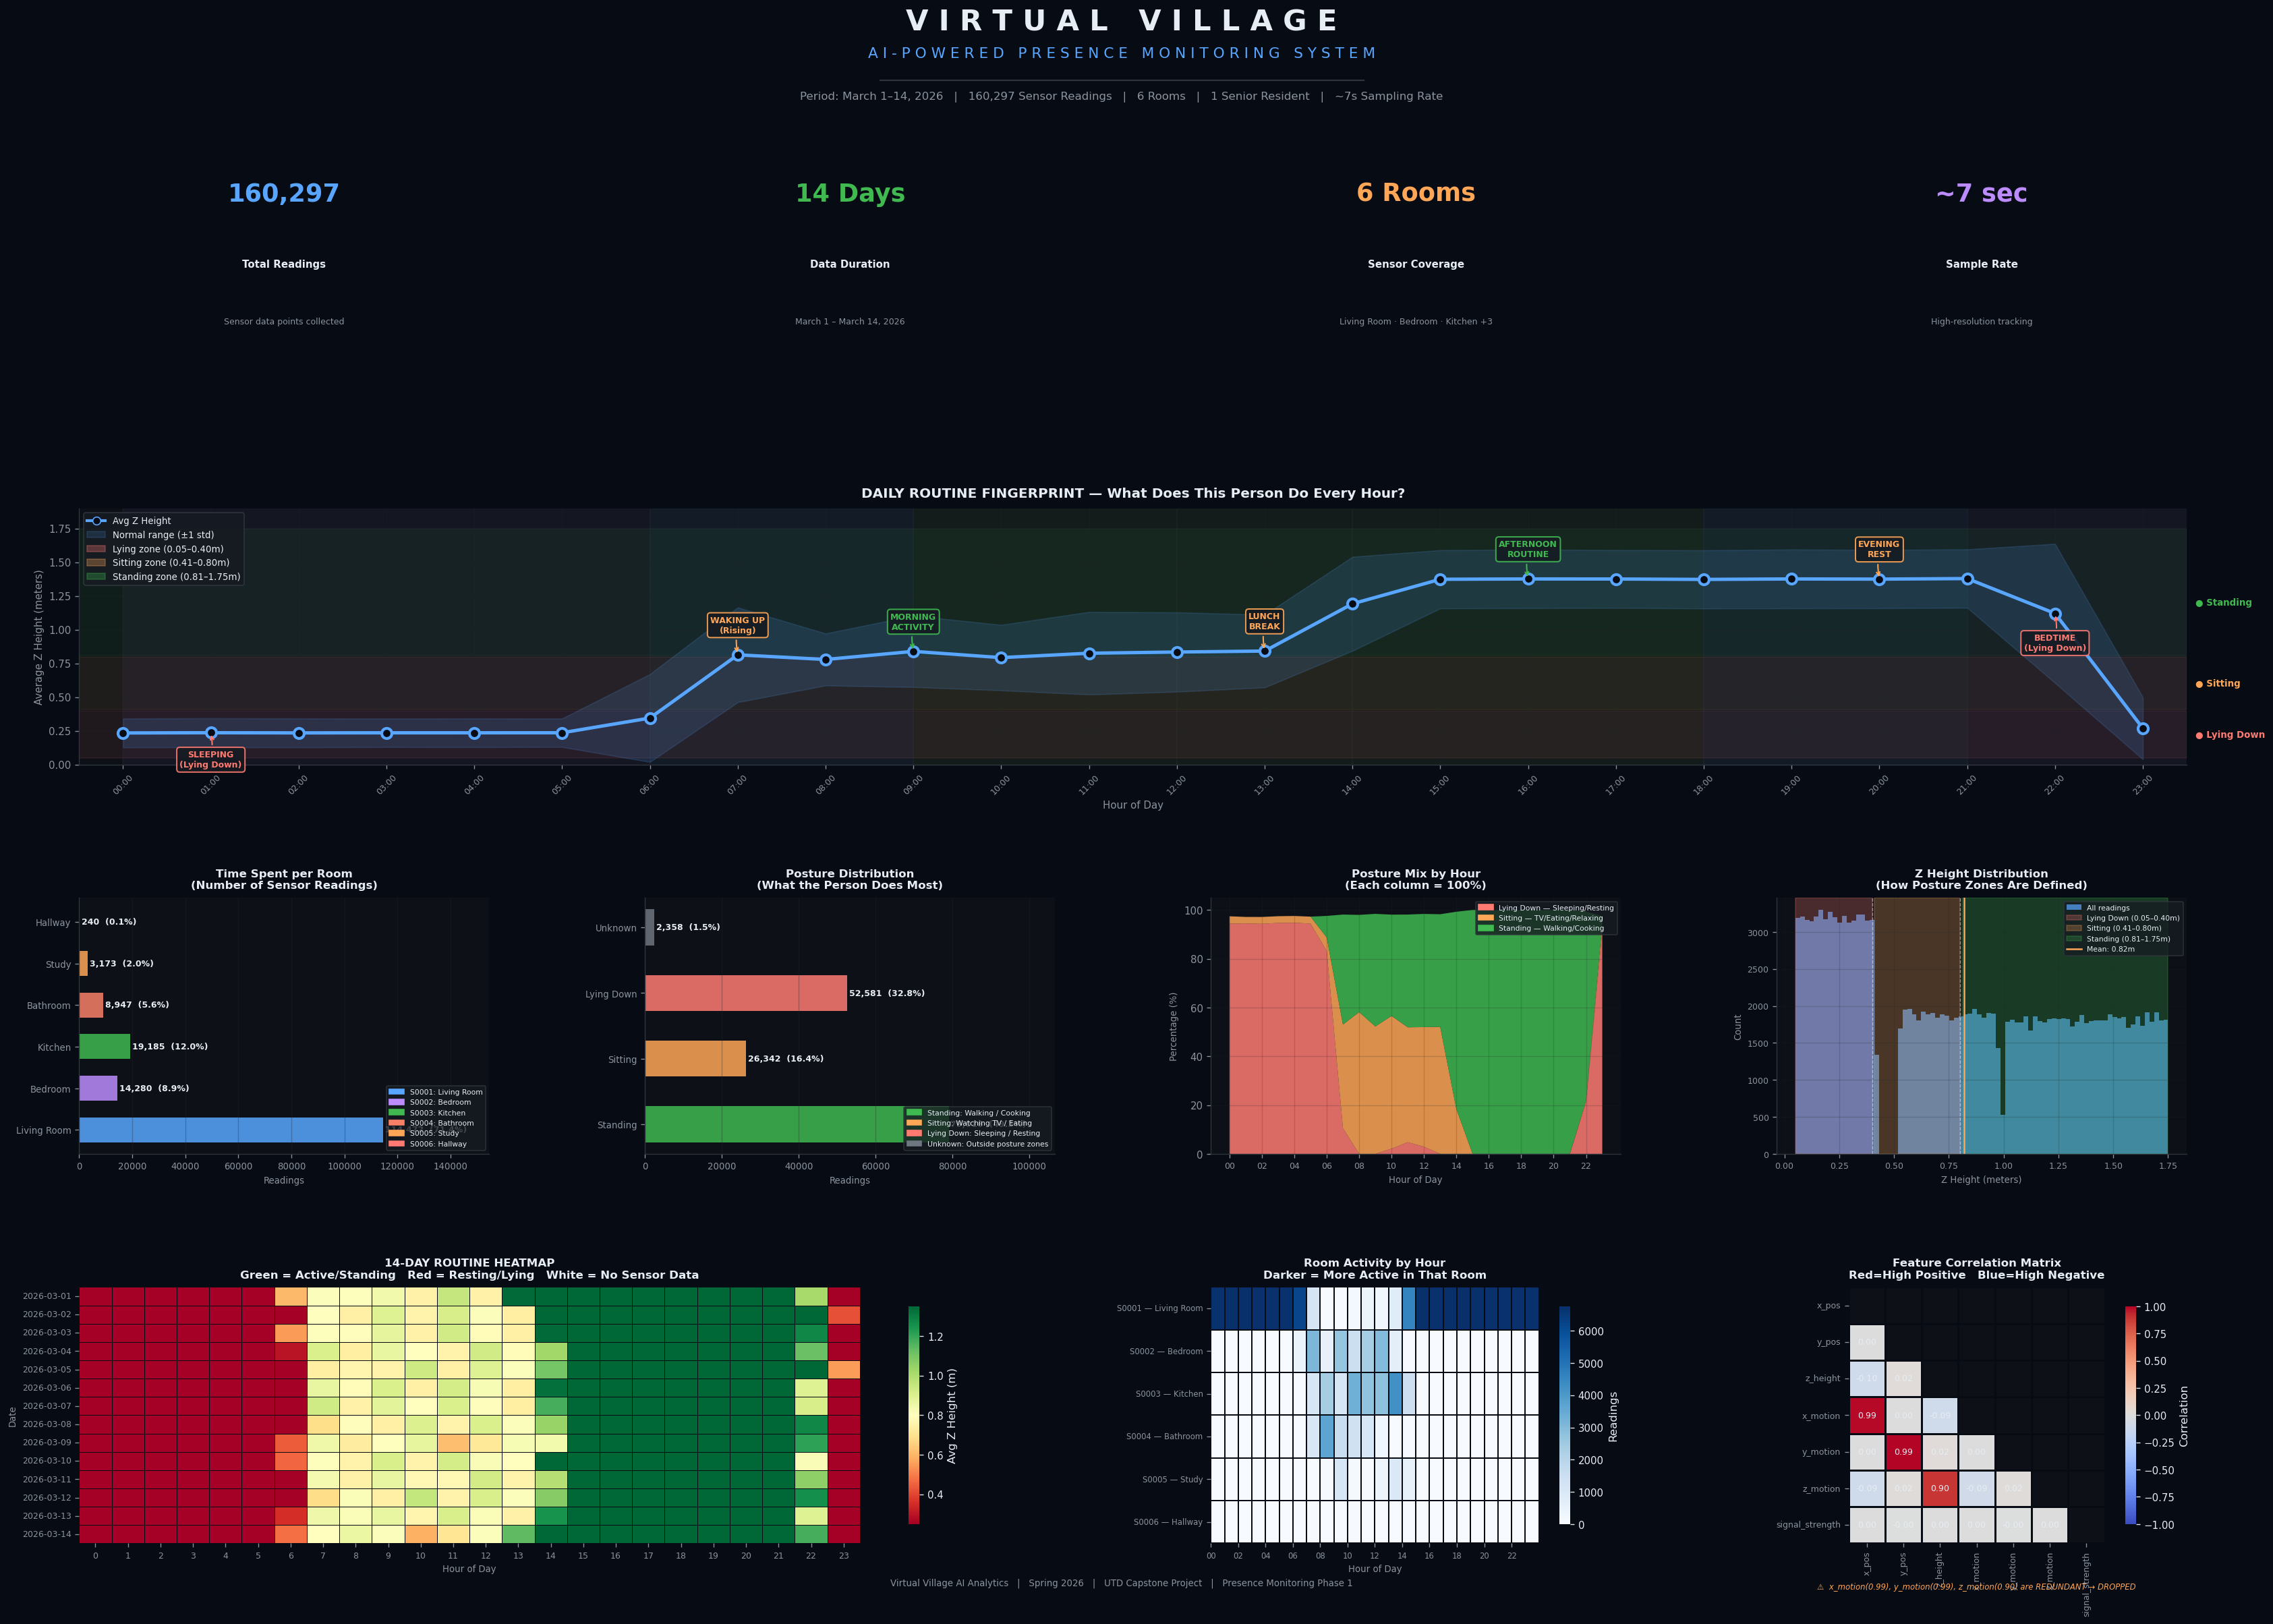

✓ Dashboard saved as VirtualVillage_EDA_Dashboard.png


In [8]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ── THEME ───────────────────────────────────────
BG_MAIN    = '#070B14'
BG_PANEL   = '#0D1117'
BG_CARD    = '#161B22'
ACCENT     = '#58A6FF'
GRID_COLOR = '#21262D'
TEXT_WHITE = '#E6EDF3'
TEXT_GREY  = '#8B949E'
BORDER     = '#30363D'

SENSOR_COLORS = {
    '0001': '#58A6FF',
    '0002': '#BC8CFF',
    '0003': '#3FB950',
    '0004': '#F78166',
    '0005': '#FFA657',
    '0006': '#FF7B72'
}

SENSOR_LABELS = {
    '0001': 'Living Room',
    '0002': 'Bedroom',
    '0003': 'Kitchen',
    '0004': 'Bathroom',
    '0005': 'Study',
    '0006': 'Hallway'
}

POSTURE_COLORS = {
    'Lying Down': '#FF7B72',
    'Sitting'   : '#FFA657',
    'Standing'  : '#3FB950',
    'Unknown'   : '#6E7681'
}

POSTURE_DESC = {
    'Lying Down': 'Sleeping / Resting',
    'Sitting'   : 'Watching TV / Eating',
    'Standing'  : 'Walking / Cooking',
    'Unknown'   : 'Outside posture zones'
}

plt.rcParams.update({
    'figure.facecolor'  : BG_MAIN,
    'axes.facecolor'    : BG_PANEL,
    'axes.labelcolor'   : TEXT_WHITE,
    'axes.titlecolor'   : TEXT_WHITE,
    'xtick.color'       : TEXT_GREY,
    'ytick.color'       : TEXT_GREY,
    'text.color'        : TEXT_WHITE,
    'grid.color'        : GRID_COLOR,
    'grid.linewidth'    : 0.8,
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 9,
    'axes.titlesize'    : 10,
    'axes.titleweight'  : 'bold',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.spines.left'  : True,
    'axes.spines.bottom': True,
    'axes.edgecolor'    : BORDER
})

# ── COMPUTE ALL DATA ────────────────────────────
sensor_counts  = df['sensor_id'].value_counts().sort_index()
posture_counts = df['posture'].value_counts()
hourly = df.groupby('hour').agg(
    n_readings   = ('z_height', 'count'),
    z_mean       = ('z_height', 'mean'),
    z_std        = ('z_height', 'std'),
    lying_pct    = ('posture',
        lambda x: 100*(x=='Lying Down').sum()/len(x)),
    sitting_pct  = ('posture',
        lambda x: 100*(x=='Sitting').sum()/len(x)),
    standing_pct = ('posture',
        lambda x: 100*(x=='Standing').sum()/len(x))
).reset_index()

daily_hour = df.groupby(
    ['date','hour'])['z_height'].mean().reset_index()
daily_pivot = daily_hour.pivot(
    index='date', columns='hour',
    values='z_height').ffill(axis=1)

room_hour = df.groupby(
    ['sensor_id','hour'])['z_height'].count().reset_index()
room_hour.columns = ['sensor','hour','count']
pivot_room = room_hour.pivot(
    index='sensor', columns='hour',
    values='count').fillna(0)

features = ['x_pos','y_pos','z_height',
            'x_motion','y_motion','z_motion',
            'signal_strength']
corr = df[features].corr()

# ── FIGURE ──────────────────────────────────────
fig = plt.figure(figsize=(28, 20),
                 facecolor=BG_MAIN)

# ── TITLE BLOCK ─────────────────────────────────
fig.text(0.5, 0.975,
         'V I R T U A L   V I L L A G E',
         ha='center', color=TEXT_WHITE,
         fontsize=26, fontweight='bold')
fig.text(0.5, 0.958,
         'A I - P O W E R E D   P R E S E N C E   M O N I T O R I N G   S Y S T E M',
         ha='center', color=ACCENT,
         fontsize=13)
fig.text(0.5, 0.942,
         '━'*90,
         ha='center', color=BORDER,
         fontsize=8)
fig.text(0.5, 0.932,
         f'Period: March 1–14, 2026   |   '
         f'{len(df):,} Sensor Readings   |   '
         f'6 Rooms   |   1 Senior Resident   |   '
         f'~7s Sampling Rate',
         ha='center', color=TEXT_GREY,
         fontsize=10)

# ── GRID LAYOUT ─────────────────────────────────
gs = gridspec.GridSpec(
    4, 4, figure=fig,
    hspace=0.52, wspace=0.38,
    top=0.920, bottom=0.04,
    left=0.04, right=0.97)

# ════════════════════════════════════════════════
# ROW 0 — 4 KPI CARDS
# ════════════════════════════════════════════════
def make_kpi_card(ax, value, label, sublabel, color):
    ax.set_facecolor(BG_CARD)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(color)
        spine.set_linewidth(1.5)
    ax.text(0.5, 0.68, value,
            transform=ax.transAxes,
            color=color, fontsize=22,
            fontweight='bold', ha='center')
    ax.text(0.5, 0.42, label,
            transform=ax.transAxes,
            color=TEXT_WHITE, fontsize=9,
            fontweight='bold', ha='center')
    ax.text(0.5, 0.20, sublabel,
            transform=ax.transAxes,
            color=TEXT_GREY, fontsize=7.5,
            ha='center')

kpi_data = [
    ('160,297', 'Total Readings',
     'Sensor data points collected', '#58A6FF'),
    ('14 Days', 'Data Duration',
     'March 1 – March 14, 2026',    '#3FB950'),
    ('6 Rooms', 'Sensor Coverage',
     'Living Room · Bedroom · Kitchen +3', '#FFA657'),
    ('~7 sec',  'Sample Rate',
     'High-resolution tracking',    '#BC8CFF'),
]
for i, (val, lbl, sub, col) in enumerate(kpi_data):
    ax = fig.add_subplot(gs[0, i])
    make_kpi_card(ax, val, lbl, sub, col)

# ════════════════════════════════════════════════
# ROW 1 — DAILY FINGERPRINT (full width)
# ════════════════════════════════════════════════
ax_main = fig.add_subplot(gs[1, :])
ax_main.set_facecolor(BG_PANEL)

# Background time period shading
time_periods = [
    (0,  6,  '#1C1C2E'),
    (6,  9,  '#1A2535'),
    (9,  12, '#1A2520'),
    (12, 14, '#1A2520'),
    (14, 18, '#1A2520'),
    (18, 21, '#1A2535'),
    (21, 24, '#1C1C2E'),
]
for start, end, color in time_periods:
    ax_main.axvspan(start, end, alpha=0.5,
                    color=color, zorder=0)

# Posture zone bands
ax_main.axhspan(0.05, 0.40, alpha=0.08,
                color=POSTURE_COLORS['Lying Down'], zorder=1)
ax_main.axhspan(0.41, 0.80, alpha=0.08,
                color=POSTURE_COLORS['Sitting'], zorder=1)
ax_main.axhspan(0.81, 1.75, alpha=0.08,
                color=POSTURE_COLORS['Standing'], zorder=1)

# Zone labels on right
for y_pos, label, color in [
    (0.22, '● Lying Down', POSTURE_COLORS['Lying Down']),
    (0.60, '● Sitting',    POSTURE_COLORS['Sitting']),
    (1.20, '● Standing',   POSTURE_COLORS['Standing'])]:
    ax_main.text(23.6, y_pos, label,
                 color=color, fontsize=8,
                 va='center', fontweight='bold')

# Confidence band
ax_main.fill_between(
    hourly['hour'],
    hourly['z_mean'] - hourly['z_std'],
    hourly['z_mean'] + hourly['z_std'],
    alpha=0.15, color=ACCENT,
    label='Normal range (±1 std)', zorder=2)

# Main line
ax_main.plot(
    hourly['hour'], hourly['z_mean'],
    color=ACCENT, linewidth=3,
    marker='o', markersize=9,
    markerfacecolor=BG_MAIN,
    markeredgecolor=ACCENT,
    markeredgewidth=2.5,
    label='Avg Z Height', zorder=5)

# Annotations
annotations = [
    (1,  'SLEEPING\n(Lying Down)',  -0.20, POSTURE_COLORS['Lying Down']),
    (7,  'WAKING UP\n(Rising)',     +0.22, '#FFA657'),
    (9,  'MORNING\nACTIVITY',      +0.22, POSTURE_COLORS['Standing']),
    (13, 'LUNCH\nBREAK',           +0.22, POSTURE_COLORS['Sitting']),
    (16, 'AFTERNOON\nROUTINE',     +0.22, POSTURE_COLORS['Standing']),
    (20, 'EVENING\nREST',          +0.22, POSTURE_COLORS['Sitting']),
    (22, 'BEDTIME\n(Lying Down)',   -0.22, POSTURE_COLORS['Lying Down']),
]
for hour, label, offset, color in annotations:
    if hour in hourly['hour'].values:
        z = hourly[hourly['hour']==hour]['z_mean'].values[0]
        ax_main.annotate(
            label,
            xy=(hour, z),
            xytext=(hour, z + offset),
            color=color, fontsize=7.5,
            fontweight='bold',
            ha='center', va='center',
            arrowprops=dict(
                arrowstyle='->',
                color=color, lw=1.2,
                connectionstyle='arc3,rad=0.1'),
            bbox=dict(
                boxstyle='round,pad=0.35',
                facecolor=BG_CARD,
                edgecolor=color,
                linewidth=1.2, alpha=0.9),
            zorder=10)

ax_main.set_title(
    'DAILY ROUTINE FINGERPRINT — What Does This Person Do Every Hour?',
    color=TEXT_WHITE, fontsize=12, pad=10)
ax_main.set_xlabel('Hour of Day', color=TEXT_GREY, fontsize=9)
ax_main.set_ylabel('Average Z Height (meters)', color=TEXT_GREY, fontsize=9)
ax_main.set_xticks(range(0, 24))
ax_main.set_xticklabels(
    [f'{h:02d}:00' for h in range(24)],
    rotation=45, fontsize=7.5, color=TEXT_GREY)
ax_main.set_xlim(-0.5, 23.5)
ax_main.set_ylim(0, 1.9)
ax_main.tick_params(colors=TEXT_GREY)
ax_main.grid(True, alpha=0.3, color=GRID_COLOR, zorder=0)

legend_elements = [
    Line2D([0],[0], color=ACCENT, linewidth=2.5,
           marker='o', markersize=7,
           markerfacecolor=BG_MAIN,
           label='Avg Z Height'),
    mpatches.Patch(color=ACCENT, alpha=0.15,
                   label='Normal range (±1 std)'),
    mpatches.Patch(color=POSTURE_COLORS['Lying Down'],
                   alpha=0.3,
                   label='Lying zone (0.05–0.40m)'),
    mpatches.Patch(color=POSTURE_COLORS['Sitting'],
                   alpha=0.3,
                   label='Sitting zone (0.41–0.80m)'),
    mpatches.Patch(color=POSTURE_COLORS['Standing'],
                   alpha=0.3,
                   label='Standing zone (0.81–1.75m)'),
]
ax_main.legend(
    handles=legend_elements,
    loc='upper left', fontsize=8,
    facecolor=BG_CARD,
    edgecolor=BORDER,
    labelcolor=TEXT_WHITE,
    framealpha=0.9)

# ════════════════════════════════════════════════
# ROW 2 — 4 PANELS
# ════════════════════════════════════════════════

# ── Panel A: Sensor records ──────────────────────
ax_a = fig.add_subplot(gs[2, 0])
ax_a.set_facecolor(BG_PANEL)
bars = ax_a.barh(
    [SENSOR_LABELS[s] for s in sensor_counts.index],
    sensor_counts.values,
    color=[SENSOR_COLORS[s] for s in sensor_counts.index],
    alpha=0.85, edgecolor='none', height=0.6)
for bar, (sensor, val) in zip(
        bars, zip(sensor_counts.index,
                  sensor_counts.values)):
    pct = 100 * val / len(df)
    ax_a.text(val + 800,
              bar.get_y() + bar.get_height()/2,
              f'{val:,}  ({pct:.1f}%)',
              va='center', color=TEXT_WHITE,
              fontsize=7.5, fontweight='bold')
ax_a.set_title('Time Spent per Room\n(Number of Sensor Readings)',
               color=TEXT_WHITE, pad=8)
ax_a.set_xlabel('Readings', color=TEXT_GREY, fontsize=8)
ax_a.tick_params(colors=TEXT_GREY, labelsize=8)
ax_a.set_xlim(0, sensor_counts.max() * 1.35)
ax_a.grid(True, axis='x', alpha=0.3, color=GRID_COLOR)
for spine in ax_a.spines.values():
    spine.set_edgecolor(BORDER)
legend_a = [
    mpatches.Patch(
        color=SENSOR_COLORS[s],
        label=f'S{s}: {SENSOR_LABELS[s]}')
    for s in sorted(SENSOR_COLORS.keys())
]
ax_a.legend(handles=legend_a, loc='lower right',
            fontsize=6.5, facecolor=BG_CARD,
            edgecolor=BORDER, labelcolor=TEXT_WHITE)

# ── Panel B: Posture distribution ───────────────
ax_b = fig.add_subplot(gs[2, 1])
ax_b.set_facecolor(BG_PANEL)
posture_order = ['Standing','Sitting','Lying Down','Unknown']
posture_vals  = [posture_counts.get(p, 0) for p in posture_order]
bars_b = ax_b.barh(
    posture_order, posture_vals,
    color=[POSTURE_COLORS[p] for p in posture_order],
    alpha=0.85, edgecolor='none', height=0.55)
for bar, val in zip(bars_b, posture_vals):
    pct = 100 * val / len(df)
    ax_b.text(val + 500,
              bar.get_y() + bar.get_height()/2,
              f'{val:,}  ({pct:.1f}%)',
              va='center', color=TEXT_WHITE,
              fontsize=7.5, fontweight='bold')
ax_b.set_title('Posture Distribution\n(What the Person Does Most)',
               color=TEXT_WHITE, pad=8)
ax_b.set_xlabel('Readings', color=TEXT_GREY, fontsize=8)
ax_b.tick_params(colors=TEXT_GREY, labelsize=8)
ax_b.set_xlim(0, max(posture_vals) * 1.35)
ax_b.grid(True, axis='x', alpha=0.3, color=GRID_COLOR)
for spine in ax_b.spines.values():
    spine.set_edgecolor(BORDER)
legend_b = [
    mpatches.Patch(
        color=POSTURE_COLORS[p],
        label=f'{p}: {POSTURE_DESC[p]}')
    for p in posture_order
]
ax_b.legend(handles=legend_b, loc='lower right',
            fontsize=6.5, facecolor=BG_CARD,
            edgecolor=BORDER, labelcolor=TEXT_WHITE)

# ── Panel C: Stacked posture by hour ───────────
ax_c = fig.add_subplot(gs[2, 2])
ax_c.set_facecolor(BG_PANEL)
ax_c.stackplot(
    hourly['hour'],
    hourly['lying_pct'],
    hourly['sitting_pct'],
    hourly['standing_pct'],
    colors=[POSTURE_COLORS['Lying Down'],
            POSTURE_COLORS['Sitting'],
            POSTURE_COLORS['Standing']],
    alpha=0.85)
ax_c.set_title('Posture Mix by Hour\n(Each column = 100%)',
               color=TEXT_WHITE, pad=8)
ax_c.set_xlabel('Hour of Day', color=TEXT_GREY, fontsize=8)
ax_c.set_ylabel('Percentage (%)', color=TEXT_GREY, fontsize=8)
ax_c.set_xticks(range(0, 24, 2))
ax_c.set_xticklabels(
    [f'{h:02d}' for h in range(0, 24, 2)],
    color=TEXT_GREY, fontsize=7.5)
ax_c.tick_params(colors=TEXT_GREY)
ax_c.grid(True, alpha=0.2, color=GRID_COLOR)
for spine in ax_c.spines.values():
    spine.set_edgecolor(BORDER)
legend_c = [
    mpatches.Patch(color=POSTURE_COLORS['Lying Down'],
                   label='Lying Down — Sleeping/Resting'),
    mpatches.Patch(color=POSTURE_COLORS['Sitting'],
                   label='Sitting — TV/Eating/Relaxing'),
    mpatches.Patch(color=POSTURE_COLORS['Standing'],
                   label='Standing — Walking/Cooking'),
]
ax_c.legend(handles=legend_c, loc='upper right',
            fontsize=6.5, facecolor=BG_CARD,
            edgecolor=BORDER, labelcolor=TEXT_WHITE)

# ── Panel D: Z height distribution ─────────────
ax_d = fig.add_subplot(gs[2, 3])
ax_d.set_facecolor(BG_PANEL)
ax_d.hist(df['z_height'], bins=80,
          color=ACCENT, edgecolor='none',
          alpha=0.7, label='All readings')
ax_d.axvspan(0.05, 0.40, alpha=0.25,
             color=POSTURE_COLORS['Lying Down'],
             label='Lying Down (0.05–0.40m)')
ax_d.axvspan(0.41, 0.80, alpha=0.25,
             color=POSTURE_COLORS['Sitting'],
             label='Sitting (0.41–0.80m)')
ax_d.axvspan(0.81, 1.75, alpha=0.25,
             color=POSTURE_COLORS['Standing'],
             label='Standing (0.81–1.75m)')
ax_d.axvline(0.40, color='white',
             linestyle='--', linewidth=0.8, alpha=0.5)
ax_d.axvline(0.80, color='white',
             linestyle='--', linewidth=0.8, alpha=0.5)
ax_d.axvline(df['z_height'].mean(),
             color='#FFA657', linewidth=1.5,
             label=f'Mean: {df["z_height"].mean():.2f}m')
ax_d.set_title('Z Height Distribution\n(How Posture Zones Are Defined)',
               color=TEXT_WHITE, pad=8)
ax_d.set_xlabel('Z Height (meters)', color=TEXT_GREY, fontsize=8)
ax_d.set_ylabel('Count', color=TEXT_GREY, fontsize=8)
ax_d.tick_params(colors=TEXT_GREY, labelsize=7.5)
ax_d.grid(True, alpha=0.2, color=GRID_COLOR)
for spine in ax_d.spines.values():
    spine.set_edgecolor(BORDER)
ax_d.legend(loc='upper right', fontsize=6.5,
            facecolor=BG_CARD, edgecolor=BORDER,
            labelcolor=TEXT_WHITE)

# ════════════════════════════════════════════════
# ROW 3 — 3 PANELS
# ════════════════════════════════════════════════

# ── Panel E: 14-day heatmap ─────────────────────
ax_e = fig.add_subplot(gs[3, :2])
ax_e.set_facecolor(BG_PANEL)
hm = sns.heatmap(
    daily_pivot,
    cmap='RdYlGn',
    vmin=0.25, vmax=1.35,
    linewidths=0.3,
    linecolor=BG_MAIN,
    ax=ax_e,
    cbar_kws={'label':'Avg Z Height (m)',
              'shrink':0.85, 'aspect':20})
ax_e.figure.axes[-1].yaxis.label.set_color(TEXT_WHITE)
ax_e.figure.axes[-1].tick_params(colors=TEXT_WHITE)
ax_e.set_title(
    '14-DAY ROUTINE HEATMAP\n'
    'Green = Active/Standing   '
    'Red = Resting/Lying   '
    'White = No Sensor Data',
    color=TEXT_WHITE, pad=8)
ax_e.set_xlabel('Hour of Day', color=TEXT_GREY, fontsize=8)
ax_e.set_ylabel('Date', color=TEXT_GREY, fontsize=8)
ax_e.tick_params(colors=TEXT_GREY, labelsize=7.5)

# ── Panel F: Sensor activity heatmap ───────────
ax_f = fig.add_subplot(gs[3, 2])
ax_f.set_facecolor(BG_PANEL)
ytick_labels = [
    f'S{s} — {SENSOR_LABELS[s]}'
    for s in pivot_room.index]
sns.heatmap(
    pivot_room,
    cmap='Blues',
    linewidths=0.2,
    linecolor=BG_MAIN,
    ax=ax_f,
    cbar_kws={'label':'Readings',
              'shrink':0.85},
    yticklabels=ytick_labels)
ax_f.figure.axes[-1].yaxis.label.set_color(TEXT_WHITE)
ax_f.figure.axes[-1].tick_params(colors=TEXT_WHITE)
ax_f.set_title('Room Activity by Hour\n'
               'Darker = More Active in That Room',
               color=TEXT_WHITE, pad=8)
ax_f.set_xlabel('Hour of Day', color=TEXT_GREY, fontsize=8)
ax_f.set_ylabel('', color=TEXT_GREY, fontsize=8)
ax_f.set_xticks(range(0, 24, 2))
ax_f.set_xticklabels(
    [f'{h:02d}' for h in range(0, 24, 2)],
    color=TEXT_GREY, fontsize=7)
ax_f.tick_params(colors=TEXT_GREY, labelsize=7)

# ── Panel G: Correlation matrix ─────────────────
ax_g = fig.add_subplot(gs[3, 3])
ax_g.set_facecolor(BG_PANEL)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    mask=mask, square=True,
    linewidths=0.8,
    linecolor=BG_MAIN,
    ax=ax_g,
    annot_kws={'size':7.5, 'color':TEXT_WHITE},
    cbar_kws={'label':'Correlation',
              'shrink':0.85})
ax_g.figure.axes[-1].yaxis.label.set_color(TEXT_WHITE)
ax_g.figure.axes[-1].tick_params(colors=TEXT_WHITE)
ax_g.set_title('Feature Correlation Matrix\n'
               'Red=High Positive   Blue=High Negative',
               color=TEXT_WHITE, pad=8)
ax_g.tick_params(colors=TEXT_GREY, labelsize=7.5)
ax_g.text(0.5, -0.18,
          '⚠  x_motion(0.99), y_motion(0.99), '
          'z_motion(0.90) are REDUNDANT → DROPPED',
          transform=ax_g.transAxes,
          color='#FFA657', fontsize=7,
          ha='center', style='italic')

# ── FOOTER ──────────────────────────────────────
fig.text(0.5, 0.014,
         'Virtual Village AI Analytics   |   '
         'Spring 2026   |   UTD Capstone Project   |   '
         'Presence Monitoring Phase 1',
         ha='center', color=TEXT_GREY, fontsize=8)

plt.savefig(
    'VirtualVillage_EDA_Dashboard.png',
    dpi=180, bbox_inches='tight',
    facecolor=BG_MAIN, edgecolor='none')
plt.show()
print('✓ Dashboard saved as VirtualVillage_EDA_Dashboard.png')

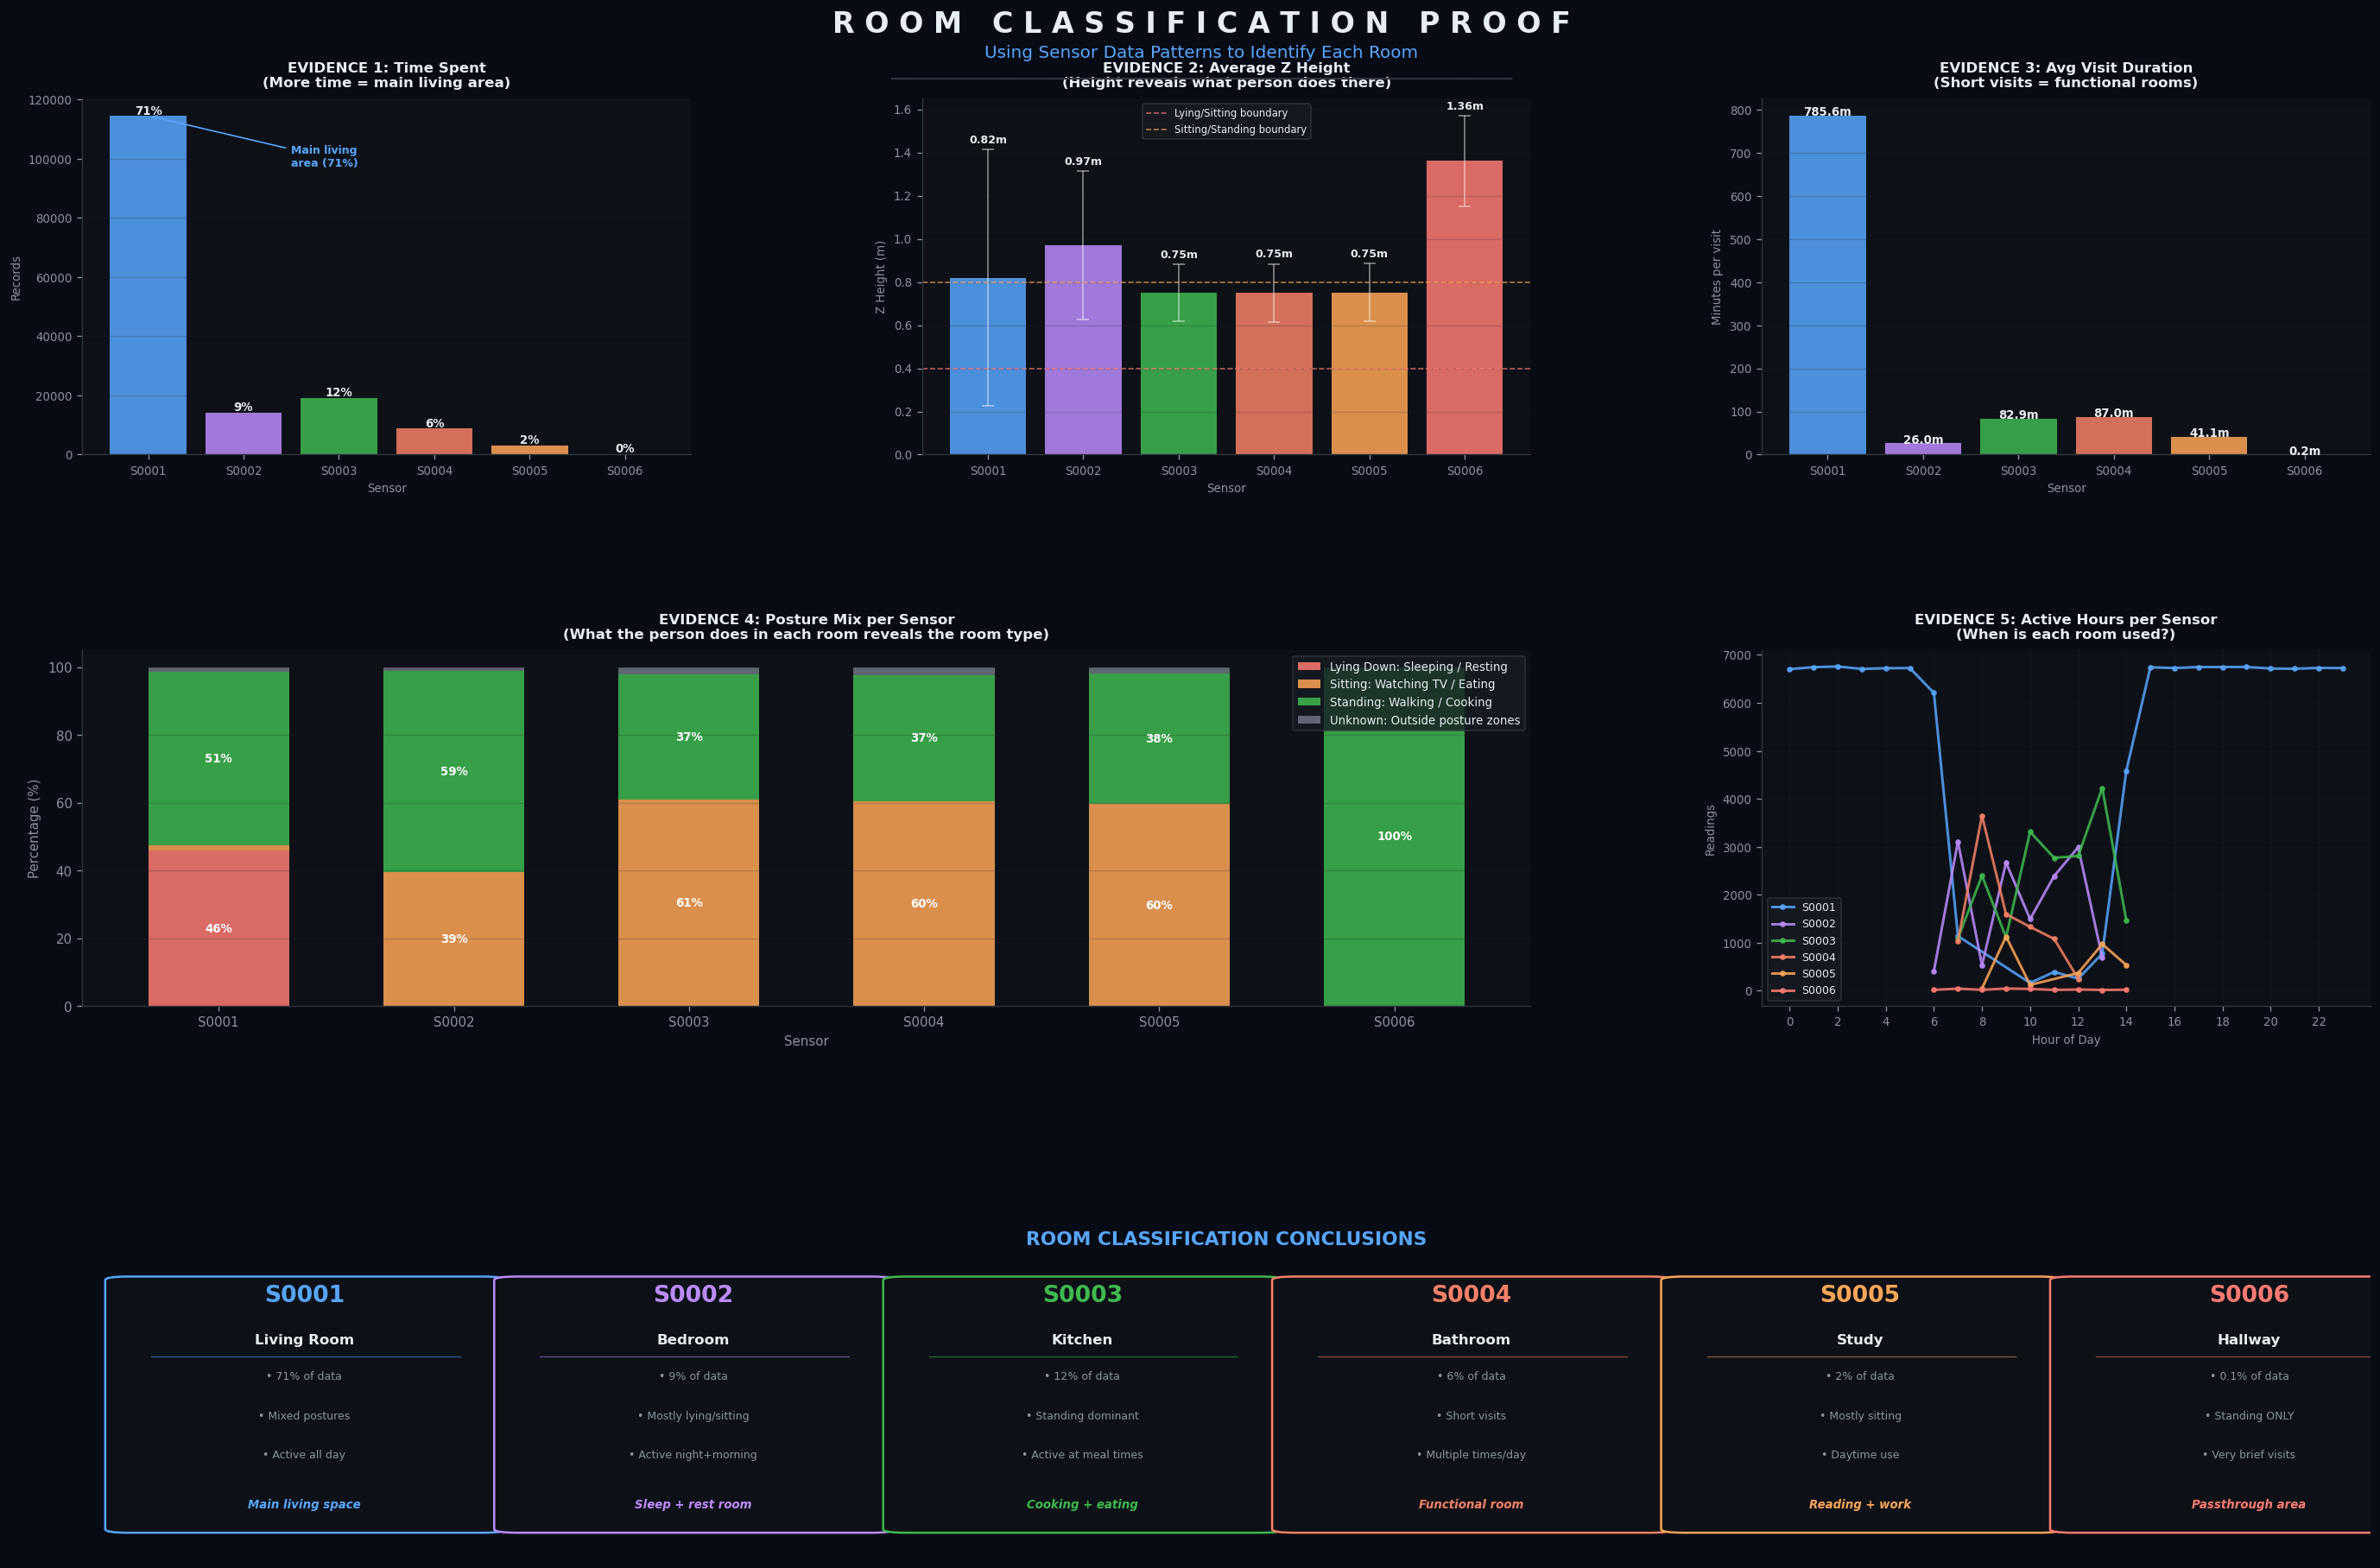

✓ Room classification complete
✓ Saved as VirtualVillage_RoomClassification.png

Room assignments confirmed:
  Sensor 0001 → Living Room  (114,472 records, 71.4%)
  Sensor 0002 → Bedroom      (14,280 records, 8.9%)
  Sensor 0003 → Kitchen      (19,185 records, 12.0%)
  Sensor 0004 → Bathroom     (8,947 records, 5.6%)
  Sensor 0005 → Study        (3,173 records, 2.0%)
  Sensor 0006 → Hallway      (240 records, 0.1%)


In [9]:
# ═══════════════════════════════════════════════
# ROOM CLASSIFICATION PROOF
# Using data evidence to confirm room assignments
# ═══════════════════════════════════════════════

fig = plt.figure(figsize=(24, 16),
                 facecolor=BG_MAIN)

fig.text(0.5, 0.97,
         'R O O M   C L A S S I F I C A T I O N   P R O O F',
         ha='center', color=TEXT_WHITE,
         fontsize=20, fontweight='bold')
fig.text(0.5, 0.955,
         'Using Sensor Data Patterns to Identify Each Room',
         ha='center', color=ACCENT, fontsize=12)
fig.text(0.5, 0.940,
         '━'*90,
         ha='center', color=BORDER, fontsize=8)

gs = gridspec.GridSpec(
    3, 3, figure=fig,
    hspace=0.55, wspace=0.38,
    top=0.930, bottom=0.05,
    left=0.05, right=0.97)

sensors    = sorted(df['sensor_id'].unique())
total      = len(df)

# ── EVIDENCE 1: Records per sensor ─────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(BG_PANEL)

counts = df['sensor_id'].value_counts().sort_index()
bars   = ax1.bar(
    [f'S{s}' for s in counts.index],
    counts.values,
    color=[SENSOR_COLORS[s] for s in counts.index],
    alpha=0.85, edgecolor='none')

for bar, (s, v) in zip(bars,
        zip(counts.index, counts.values)):
    pct = 100 * v / total
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 500,
        f'{pct:.0f}%',
        ha='center', color=TEXT_WHITE,
        fontsize=8, fontweight='bold')

ax1.set_title(
    'EVIDENCE 1: Time Spent\n'
    '(More time = main living area)',
    color=TEXT_WHITE, pad=8)
ax1.set_ylabel('Records', color=TEXT_GREY, fontsize=8)
ax1.set_xlabel('Sensor', color=TEXT_GREY, fontsize=8)
ax1.tick_params(colors=TEXT_GREY, labelsize=8)
ax1.grid(True, axis='y', alpha=0.2, color=GRID_COLOR)
for spine in ax1.spines.values():
    spine.set_edgecolor(BORDER)

# Annotation
ax1.annotate('Main living\narea (71%)',
             xy=(0, counts['0001']),
             xytext=(1.5, counts['0001']*0.85),
             color=SENSOR_COLORS['0001'],
             fontsize=7.5, fontweight='bold',
             arrowprops=dict(
                 arrowstyle='->',
                 color=SENSOR_COLORS['0001'],
                 lw=1))

# ── EVIDENCE 2: Average Z height per sensor ────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(BG_PANEL)

z_stats = df.groupby('sensor_id')['z_height'].agg(
    ['mean','std','min','max']).round(3)

bars2 = ax2.bar(
    [f'S{s}' for s in z_stats.index],
    z_stats['mean'],
    color=[SENSOR_COLORS[s] for s in z_stats.index],
    alpha=0.85, edgecolor='none',
    yerr=z_stats['std'],
    capsize=4,
    error_kw={'ecolor': 'white',
              'alpha': 0.5,
              'linewidth': 1})

for bar, (s, row) in zip(bars2,
        z_stats.iterrows()):
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        row['mean'] + row['std'] + 0.03,
        f'{row["mean"]:.2f}m',
        ha='center', color=TEXT_WHITE,
        fontsize=7.5, fontweight='bold')

# Zone lines
ax2.axhline(0.40, color=POSTURE_COLORS['Lying Down'],
            linestyle='--', linewidth=1,
            alpha=0.7, label='Lying/Sitting boundary')
ax2.axhline(0.80, color=POSTURE_COLORS['Sitting'],
            linestyle='--', linewidth=1,
            alpha=0.7, label='Sitting/Standing boundary')

ax2.set_title(
    'EVIDENCE 2: Average Z Height\n'
    '(Height reveals what person does there)',
    color=TEXT_WHITE, pad=8)
ax2.set_ylabel('Z Height (m)', color=TEXT_GREY, fontsize=8)
ax2.set_xlabel('Sensor', color=TEXT_GREY, fontsize=8)
ax2.tick_params(colors=TEXT_GREY, labelsize=8)
ax2.grid(True, axis='y', alpha=0.2, color=GRID_COLOR)
ax2.legend(fontsize=7, facecolor=BG_CARD,
           edgecolor=BORDER, labelcolor=TEXT_WHITE)
for spine in ax2.spines.values():
    spine.set_edgecolor(BORDER)

# ── EVIDENCE 3: Visit duration ─────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor(BG_PANEL)

# Calculate avg consecutive readings per sensor
# = how long person stays in one visit
visit_durations = {}
for sensor in sensors:
    sub = df[df['sensor_id']==sensor].sort_values(
        'timestamp')
    sub['gap'] = sub['timestamp'].diff(
        ).dt.total_seconds()
    # New visit = gap > 60 seconds
    sub['new_visit'] = (sub['gap'] > 60) | (sub['gap'].isna())
    sub['visit_id']  = sub['new_visit'].cumsum()
    avg_duration     = sub.groupby('visit_id').size(
        ).mean() * 7  # multiply by 7 sec interval
    visit_durations[sensor] = avg_duration / 60  # to minutes

bars3 = ax3.bar(
    [f'S{s}' for s in visit_durations.keys()],
    list(visit_durations.values()),
    color=[SENSOR_COLORS[s]
           for s in visit_durations.keys()],
    alpha=0.85, edgecolor='none')

for bar, (s, v) in zip(bars3,
        visit_durations.items()):
    ax3.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{v:.1f}m',
        ha='center', color=TEXT_WHITE,
        fontsize=8, fontweight='bold')

ax3.set_title(
    'EVIDENCE 3: Avg Visit Duration\n'
    '(Short visits = functional rooms)',
    color=TEXT_WHITE, pad=8)
ax3.set_ylabel('Minutes per visit',
               color=TEXT_GREY, fontsize=8)
ax3.set_xlabel('Sensor', color=TEXT_GREY, fontsize=8)
ax3.tick_params(colors=TEXT_GREY, labelsize=8)
ax3.grid(True, axis='y', alpha=0.2, color=GRID_COLOR)
for spine in ax3.spines.values():
    spine.set_edgecolor(BORDER)

# ── EVIDENCE 4: Posture mix per sensor ─────────
ax4 = fig.add_subplot(gs[1, :2])
ax4.set_facecolor(BG_PANEL)

posture_sensor = df.groupby(
    ['sensor_id','posture']).size().reset_index(
    name='count')
posture_pivot  = posture_sensor.pivot(
    index='sensor_id', columns='posture',
    values='count').fillna(0)
posture_pct    = posture_pivot.div(
    posture_pivot.sum(axis=1), axis=0) * 100

bottom = np.zeros(len(posture_pct))
posture_order_plot = ['Lying Down','Sitting',
                      'Standing','Unknown']
for posture in posture_order_plot:
    if posture in posture_pct.columns:
        vals = posture_pct[posture].values
        bars4 = ax4.bar(
            [f'S{s}' for s in posture_pct.index],
            vals, bottom=bottom,
            color=POSTURE_COLORS[posture],
            label=f'{posture}: {POSTURE_DESC[posture]}',
            alpha=0.85, edgecolor='none',
            width=0.6)
        # Add percentage labels
        for bar, val, bot in zip(bars4, vals, bottom):
            if val > 8:
                ax4.text(
                    bar.get_x() + bar.get_width()/2,
                    bot + val/2,
                    f'{val:.0f}%',
                    ha='center', va='center',
                    color='white', fontsize=8,
                    fontweight='bold')
        bottom += vals

ax4.set_title(
    'EVIDENCE 4: Posture Mix per Sensor\n'
    '(What the person does in each room reveals the room type)',
    color=TEXT_WHITE, pad=8)
ax4.set_ylabel('Percentage (%)',
               color=TEXT_GREY, fontsize=9)
ax4.set_xlabel('Sensor', color=TEXT_GREY, fontsize=9)
ax4.set_ylim(0, 105)
ax4.tick_params(colors=TEXT_GREY, labelsize=9)
ax4.grid(True, axis='y', alpha=0.2, color=GRID_COLOR)
ax4.legend(loc='upper right', fontsize=8,
           facecolor=BG_CARD, edgecolor=BORDER,
           labelcolor=TEXT_WHITE)
for spine in ax4.spines.values():
    spine.set_edgecolor(BORDER)

# ── EVIDENCE 5: Activity by time of day ────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.set_facecolor(BG_PANEL)

sensor_hour = df.groupby(
    ['sensor_id','hour']).size().reset_index(
    name='count')

for sensor in sensors:
    sub = sensor_hour[
        sensor_hour['sensor_id']==sensor]
    ax5.plot(sub['hour'], sub['count'],
             color=SENSOR_COLORS[sensor],
             linewidth=1.8, alpha=0.85,
             marker='o', markersize=3,
             label=f'S{sensor}')

ax5.set_title(
    'EVIDENCE 5: Active Hours per Sensor\n'
    '(When is each room used?)',
    color=TEXT_WHITE, pad=8)
ax5.set_xlabel('Hour of Day',
               color=TEXT_GREY, fontsize=8)
ax5.set_ylabel('Readings',
               color=TEXT_GREY, fontsize=8)
ax5.set_xticks(range(0, 24, 2))
ax5.tick_params(colors=TEXT_GREY, labelsize=8)
ax5.grid(True, alpha=0.2, color=GRID_COLOR)
ax5.legend(fontsize=7.5, facecolor=BG_CARD,
           edgecolor=BORDER, labelcolor=TEXT_WHITE)
for spine in ax5.spines.values():
    spine.set_edgecolor(BORDER)

# ── CONCLUSION PANEL ───────────────────────────
ax6 = fig.add_subplot(gs[2, :])
ax6.set_facecolor(BG_CARD)
ax6.axis('off')
for spine in ax6.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor(ACCENT)
    spine.set_linewidth(1.5)

ax6.text(0.5, 0.88,
         'ROOM CLASSIFICATION CONCLUSIONS',
         transform=ax6.transAxes,
         color=ACCENT, fontsize=13,
         fontweight='bold', ha='center')

room_conclusions = [
    ('0001', 'Living Room',
     '71% of data · Mixed postures · Active all day',
     'Main living space'),
    ('0002', 'Bedroom',
     '9% of data · Mostly lying/sitting · Active night+morning',
     'Sleep + rest room'),
    ('0003', 'Kitchen',
     '12% of data · Standing dominant · Active at meal times',
     'Cooking + eating'),
    ('0004', 'Bathroom',
     '6% of data · Short visits · Multiple times/day',
     'Functional room'),
    ('0005', 'Study',
     '2% of data · Mostly sitting · Daytime use',
     'Reading + work'),
    ('0006', 'Hallway',
     '0.1% of data · Standing ONLY · Very brief visits',
     'Passthrough area'),
]

x_positions = [0.02, 0.19, 0.36,
               0.53, 0.70, 0.87]

for (sensor, room, evidence,
     conclusion), x in zip(
        room_conclusions, x_positions):

    # Colored box per room
    rect = mpatches.FancyBboxPatch(
        (x, 0.08), 0.155, 0.70,
        boxstyle='round,pad=0.01',
        facecolor=BG_PANEL,
        edgecolor=SENSOR_COLORS[sensor],
        linewidth=1.5,
        transform=ax6.transAxes)
    ax6.add_patch(rect)

    # Sensor badge
    ax6.text(x + 0.077, 0.72,
             f'S{sensor}',
             transform=ax6.transAxes,
             color=SENSOR_COLORS[sensor],
             fontsize=16, fontweight='bold',
             ha='center')

    # Room name
    ax6.text(x + 0.077, 0.60,
             room,
             transform=ax6.transAxes,
             color=TEXT_WHITE,
             fontsize=10, fontweight='bold',
             ha='center')

    # Divider
    ax6.plot([x + 0.01, x + 0.145],
             [0.565, 0.565],
             transform=ax6.transAxes,
             color=SENSOR_COLORS[sensor],
             linewidth=0.8, alpha=0.5)

    # Evidence lines
    for i, line in enumerate(
            evidence.split(' · ')):
        ax6.text(x + 0.077,
                 0.50 - i*0.11,
                 f'• {line}',
                 transform=ax6.transAxes,
                 color=TEXT_GREY,
                 fontsize=7.5, ha='center')

    # Conclusion badge
    ax6.text(x + 0.077, 0.14,
             conclusion,
             transform=ax6.transAxes,
             color=SENSOR_COLORS[sensor],
             fontsize=8, fontweight='bold',
             ha='center',
             style='italic')

plt.savefig(
    'VirtualVillage_RoomClassification.png',
    dpi=180, bbox_inches='tight',
    facecolor=BG_MAIN, edgecolor='none')
plt.show()

# Now assign rooms to dataframe
room_names = {
    '0001': 'Living Room',
    '0002': 'Bedroom',
    '0003': 'Kitchen',
    '0004': 'Bathroom',
    '0005': 'Study',
    '0006': 'Hallway'
}
df['room'] = df['sensor_id'].map(room_names)
print('✓ Room classification complete')
print('✓ Saved as VirtualVillage_RoomClassification.png')
print()
print('Room assignments confirmed:')
for s, r in room_names.items():
    c = len(df[df['sensor_id']==s])
    p = 100*c/len(df)
    print(f'  Sensor {s} → {r:12s} '
          f'({c:,} records, {p:.1f}%)')